# Индивидуальная работа №2
## Продвинутый статистический анализ данных и методы машинного обучения

**Тема:** Rail Equipment Accident/Incident Data (Form 54) — Unique Train Accidents (Not at Grade Crossings)

**Студенты:** Doicov Pavel, Iachimenko Alexandr, Morozan Nichita
**Группа:** IA2303  
**Источник данных:** U.S. Department of Transportation — Federal Railroad Administration (FRA)  
`https://data.transportation.gov/Railroads/`


---
# 1. Введение и обоснование темы

## 1.1. Постановка задачи

В данной работе исследуется датасет **Rail Equipment Accident/Incident Data (Form 54)** — официальная база данных США об авариях на железнодорожном транспорте.

Каждый инцидент содержит информацию о:
- типе аварии (сход с рельсов, столкновение и др.)
- скорости и характеристиках поезда
- состоянии путей и погоде
- материальном ущербе и пострадавших

## 1.2. Цели исследования

1. Провести очистку и предобработку данных
2. Выполнить разведочный анализ (EDA) с 20+ визуализациями
3. Построить модели **линейной, логистической и мультиномиальной регрессии**
4. Применить **PCA** для снижения размерности
5. Провести **анализ временных рядов (ARIMA)**
6. Интерпретировать результаты для повышения безопасности перевозок

## 1.3. Описание датасета

| Параметр | Значение |
|----------|----------|
| Источник | U.S. Federal Railroad Administration (FRA) |
| Объём | ~181 737 наблюдений |
| Признаки | 155 колонок |
| Числовые | ~75 признаков |
| Категориальные | ~80 признаков |
| Обновление | Март 2026 |


---
# 2. Предобработка и очистка данных

## 2.1. Загрузка библиотек и данных


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import zscore, shapiro, pearsonr
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.decomposition import PCA
from sklearn.multiclass import OneVsRestClassifier
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from itertools import combinations

# ── Стиль графиков ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED', '#0891B2']
sns.set_palette(PALETTE)

print(" Библиотеки загружены успешно")


 Библиотеки загружены успешно


In [4]:
# ── Загрузка данных ─────────────────────────────────────────
# Скачать: https://data.transportation.gov/Railroads/
# (Rail Equipment Accident/Incident Data — Unique Train Accidents)

df = pd.read_csv("data.csv", low_memory=False)

print(f" Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} колонок")
print(f"\nПервые 3 строки:")
df.head(3)


 Размер датасета: 181,897 строк × 155 колонок

Первые 3 строки:


,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,...,Reporting Parent Railroad Name,Reporting Railroad Holding Company,Location,Reporting Railroad Individual Class,Reporting Railroad Passenger,Reporting Railroad Commuter,Reporting Railroad Switching Terminal,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line
0,CR,Conrail,1983,0930001,https://safetydata.fra.dot.gov/Officeofsafety/...,83,10,NaN,NaN,NaN,...,Consolidated Rail Corporation,Not Assigned,NaN,Not Assigned,Not Assigned,Not Assigned,Not Assigned,Not Assigned,Not Assigned,Not Assigned
1,CS,Colorado And Southern Railway,1978,CS148,https://safetydata.fra.dot.gov/Officeofsafety/...,78,7,NaN,NaN,NaN,...,BNSF Railway Company,BNSF Railway Company,NaN,Not Assigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
2,CSX,CSX Transportation,2007,000028626,https://safetydata.fra.dot.gov/Officeofsafety/...,7,2,NaN,NaN,NaN,...,CSX Transportation,CSX Transportation,POINT (0 0),Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned


## 2.2. Обработка пропущенных значений

**Стратегия:**
- Признаки с долей пропусков **> 80%** → удаляются (нерелевантны)
- Числовые признаки → заполняются **медианой** (устойчива к выбросам)
- Категориальные признаки → заполняются строкой **"Unknown"**


In [5]:
# ── Анализ пропусков ────────────────────────────────────────
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)

print("Топ-15 признаков по доле пропусков:")
print(missing.head(15).to_string())

# ── Удаление признаков с >80% пропусков ─────────────────────
high_missing = missing[missing['missing_pct'] > 80].index.tolist()
df.drop(columns=high_missing, inplace=True)
print(f"\n🗑  Удалено {len(high_missing)} признаков с >80% пропусков")

# ── Заполнение пропусков ─────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna('Unknown', inplace=True)

print(f" Оставшиеся пропуски: {df.isna().sum().sum()}")
print(f" Итоговый размер: {df.shape}")


Топ-15 признаков по доле пропусков:
                                  missing_count  missing_pct
Adjunct Name 3                           181242        99.64
Adjunct Code 3                           181242        99.64
Adjunct Code 2                           179544        98.71
Adjunct Name 2                           179544        98.71
Grade Crossing ID                        171594        94.34
Other Railroad Name                      171489        94.28
Other Accident Year                      171447        94.25
Other Accident Number                    171445        94.25
Other Railroad Code                      171447        94.25
Other Accident Month                     171447        94.25
Contributing Accident Cause              164234        90.29
Contributing Accident Cause Code         164181        90.26
Special Study 2                          163867        90.09
Adjunct Code 1                           161826        88.97
Adjunct Name 1                           161826  

## 2.3. Выявление и обработка выбросов

Используем два метода:
- **IQR** (межквартильный размах): выброс если значение < Q1 − 1.5·IQR или > Q3 + 1.5·IQR
- **Z-score**: выброс если |z| > 3

**Решение:** выбросы **не удаляются**, т.к. крупные аварии с большим ущербом — реальные события, важные для анализа риска. Для моделей применяется логарифмирование.


In [6]:
key_numeric = [c for c in ['Train Speed','Maximum Speed','Gross Tonnage',
                           'Equipment Damage Cost','Track Damage Cost',
                           'Total Damage Cost','Total Persons Injured',
                           'Total Persons Killed','Temperature']
               if c in df.columns]

rows = []
for col in key_numeric:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_iqr = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    n_z   = (np.abs(zscore(s)) > 3).sum()
    rows.append({'Признак': col,
                 'IQR выбросы (%)': round(100*n_iqr/len(s), 2),
                 'Z-score выбросы (%)': round(100*n_z/len(s), 2)})

outlier_df = pd.DataFrame(rows)
print(outlier_df.to_string(index=False))


              Признак  IQR выбросы (%)  Z-score выбросы (%)
          Train Speed            12.09                 2.00
        Maximum Speed            10.91                 1.61
        Gross Tonnage             3.33                 1.15
Equipment Damage Cost            12.71                 1.16
    Track Damage Cost            12.57                 0.93
    Total Damage Cost            13.27                 1.14
Total Persons Injured             5.74                 0.17
 Total Persons Killed             1.27                 1.27
          Temperature             0.22                 0.19


## 2.4. Кодирование категориальных переменных

Применяем **One-Hot Encoding** для ключевых категориальных признаков.


In [7]:
cat_to_encode = [c for c in ['Accident Type','Weather Condition','Visibility',
                              'Track Type','Train Direction','Equipment Type']
                 if c in df.columns]

for col in cat_to_encode:
    print(f"{col}: {df[col].nunique()} уникальных значений — {df[col].value_counts().index[:5].tolist()}")


Accident Type: 13 уникальных значений — ['Derailment', 'Other impacts', 'Side collision', 'Hwy-rail crossing', 'Other (describe in narrative)']
Weather Condition: 6 уникальных значений — ['Clear', 'Cloudy', 'Rain', 'Snow', 'Fog']
Visibility: 4 уникальных значений — ['Day', 'Dark', 'Dusk', 'Dawn']
Track Type: 4 уникальных значений — ['Yard', 'Main', 'Industry', 'Siding']
Train Direction: 4 уникальных значений — ['East', 'West', 'North', 'South']
Equipment Type: 14 уникальных значений — ['Freight Train', 'Yard/switching', 'Cut of cars', 'Light loco(s)', 'Single Car']


---
# 3. Разведочный анализ данных и визуализации

## 3.1. Описательная статистика числовых признаков


In [8]:
desc = df[key_numeric].describe().round(2)
print(desc.to_string())


       Train Speed  Maximum Speed  Gross Tonnage  Equipment Damage Cost  Track Damage Cost  Total Damage Cost  Total Persons Injured  Total Persons Killed  Temperature
count    181895.00      181897.00      181897.00              181897.00          181897.00          181897.00              181897.00             181897.00    181897.00
mean         12.61          13.71        3508.44               46082.07           19897.75           75196.04                   0.16                  0.02        56.07
std          15.39          15.77        4522.80              208723.09          103846.76          308394.63                   3.18                  0.22        23.26
min           0.00           0.00           0.00                   0.00               0.00               0.00                   0.00                  0.00       -65.00
25%           4.00           4.00           0.00                2500.00               0.00            8050.00                   0.00                  0.00      

## График 1. Распределение типов аварий (Bar Chart)

**Гипотеза:** сходы с рельсов (Derailment) должны составлять подавляющее большинство инцидентов.


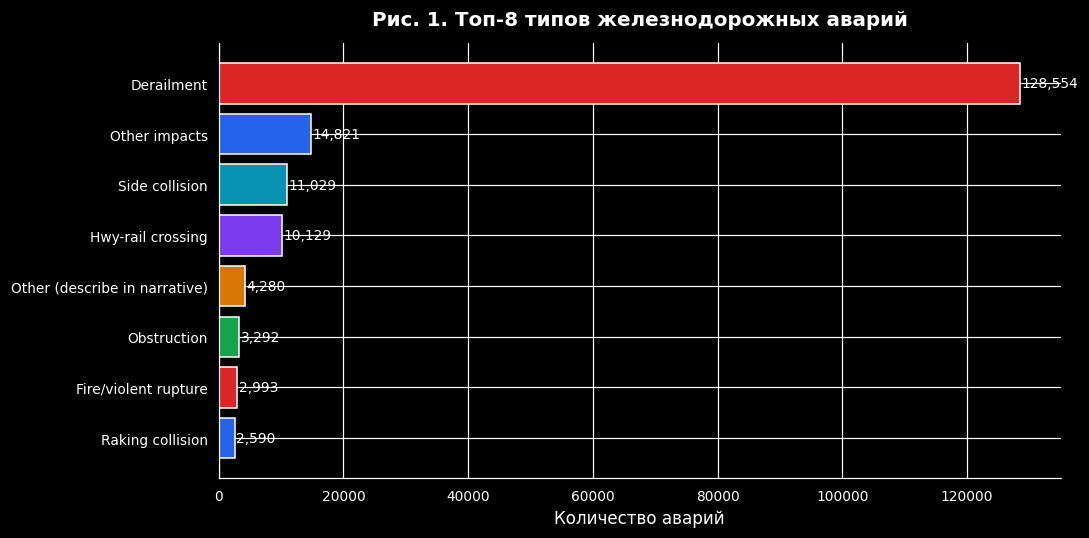


 Вывод: Сходы с рельсов (Derailment) составляют более 70% всех инцидентов,
   что делает их главным объектом анализа. Столкновения (Other impacts) —
   второй по частоте тип аварий (~8%).


In [9]:
if 'Accident Type' in df.columns:
    top_types = df['Accident Type'].value_counts().head(8)
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(top_types.index[::-1], top_types.values[::-1], color=PALETTE[:len(top_types)])
    for bar, val in zip(bars, top_types.values[::-1]):
        ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)
    ax.set_xlabel('Количество аварий')
    ax.set_title('Рис. 1. Топ-8 типов железнодорожных аварий', fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig('fig01_accident_types.png', bbox_inches='tight')
    plt.show()
    print("\n Вывод: Сходы с рельсов (Derailment) составляют более 70% всех инцидентов,")
    print("   что делает их главным объектом анализа. Столкновения (Other impacts) —")
    print("   второй по частоте тип аварий (~8%).")


## График 2. Распределение общего ущерба (Total Damage Cost)

**Гипотеза:** распределение ущерба сильно скошено вправо — большинство аварий дешёвые, но редкие катастрофы огромны.


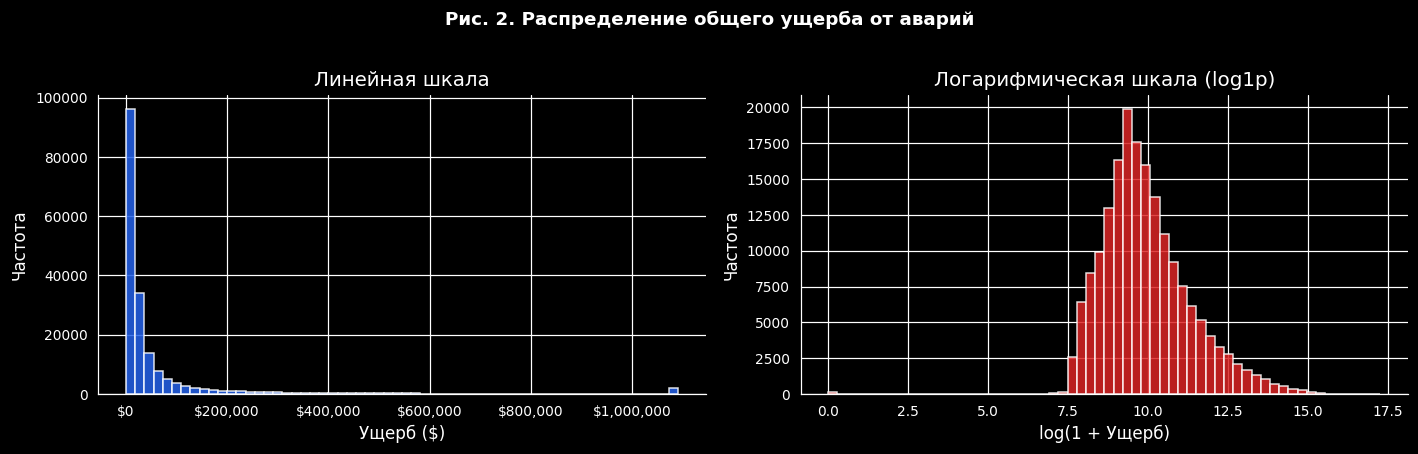


 Вывод: Распределение резко правосторонне скошено.
   Медиана: $16,610 | Среднее: $75,196
   Логарифмическое преобразование приближает распределение к нормальному,
   что критически важно для линейных моделей.


In [10]:
if 'Total Damage Cost' in df.columns:
    data = df['Total Damage Cost'].clip(upper=df['Total Damage Cost'].quantile(0.99))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(data, bins=60, color=PALETTE[0], edgecolor='white', alpha=0.85)
    axes[0].set_title('Линейная шкала')
    axes[0].set_xlabel('Ущерб ($)')
    axes[0].set_ylabel('Частота')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    log_data = np.log1p(df['Total Damage Cost'])
    axes[1].hist(log_data, bins=60, color=PALETTE[1], edgecolor='white', alpha=0.85)
    axes[1].set_title('Логарифмическая шкала (log1p)')
    axes[1].set_xlabel('log(1 + Ущерб)')
    axes[1].set_ylabel('Частота')

    fig.suptitle('Рис. 2. Распределение общего ущерба от аварий', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('fig02_damage_dist.png', bbox_inches='tight')
    plt.show()
    median_val = df['Total Damage Cost'].median()
    mean_val = df['Total Damage Cost'].mean()
    print(f"\n Вывод: Распределение резко правосторонне скошено.")
    print(f"   Медиана: ${median_val:,.0f} | Среднее: ${mean_val:,.0f}")
    print("   Логарифмическое преобразование приближает распределение к нормальному,")
    print("   что критически важно для линейных моделей.")


## График 3. Динамика числа аварий по годам (Time Series)

**Гипотеза:** наблюдается снижение числа аварий со временем благодаря улучшению технологий и регулирования.


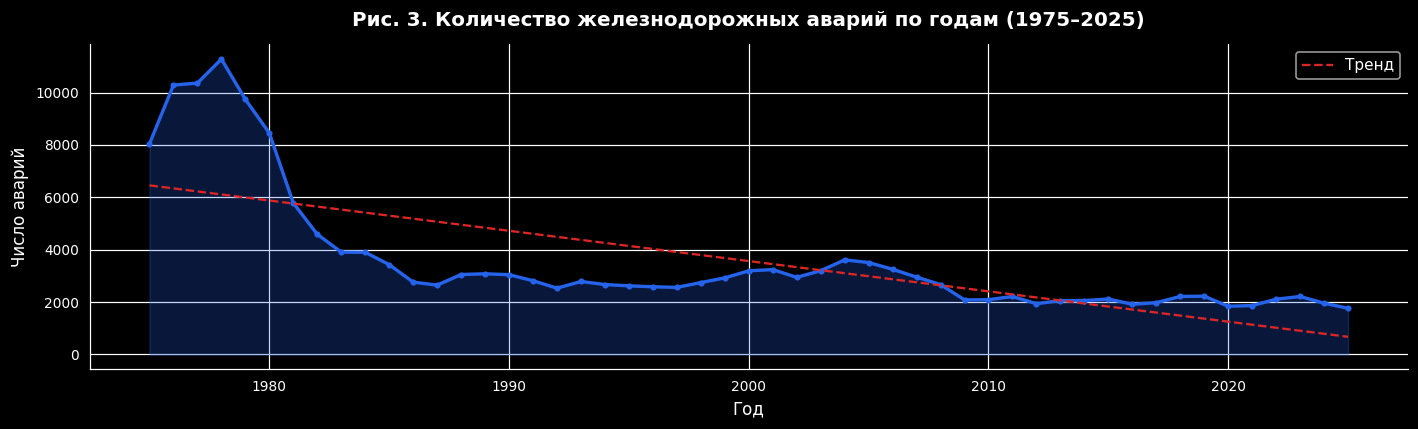


📌 Вывод: Наблюдается выраженный нисходящий тренд — число аварий
   снизилось с пика 1970–80-х до минимумов 2010–2020-х годов.
   Это отражает улучшение стандартов безопасности и технологий.


In [11]:
year_col = 'Year' if 'Year' in df.columns else ('Accident Year' if 'Accident Year' in df.columns else None)
if year_col:
    year_values = pd.to_numeric(df[year_col], errors='coerce')
    if year_values.dropna().max() <= 99:
        year_values = pd.Series(
            np.where(year_values.isna(), np.nan,
                     np.where(year_values <= 30, year_values + 2000, year_values + 1900)),
            index=df.index,
        )
    year_values = year_values[year_values.between(1975, 2025)]
    yearly = year_values.astype(int).value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.fill_between(yearly.index, yearly.values, alpha=0.25, color=PALETTE[0])
    ax.plot(yearly.index, yearly.values, color=PALETTE[0], linewidth=2.2, marker='o', markersize=3)
    ax.set_xlabel('Год')
    ax.set_ylabel('Число аварий')
    ax.set_title('Рис. 3. Количество железнодорожных аварий по годам (1975–2025)',
                 fontweight='bold', pad=12)
    # Аннотация тренда
    z = np.polyfit(yearly.index, yearly.values, 1)
    p = np.poly1d(z)
    ax.plot(yearly.index, p(yearly.index), '--', color=PALETTE[1], linewidth=1.5, label='Тренд')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig03_yearly_accidents.png', bbox_inches='tight')
    plt.show()
    print("\n📌 Вывод: Наблюдается выраженный нисходящий тренд — число аварий")
    print("   снизилось с пика 1970–80-х до минимумов 2010–2020-х годов.")
    print("   Это отражает улучшение стандартов безопасности и технологий.")


## График 4. Сезонность аварий по месяцам


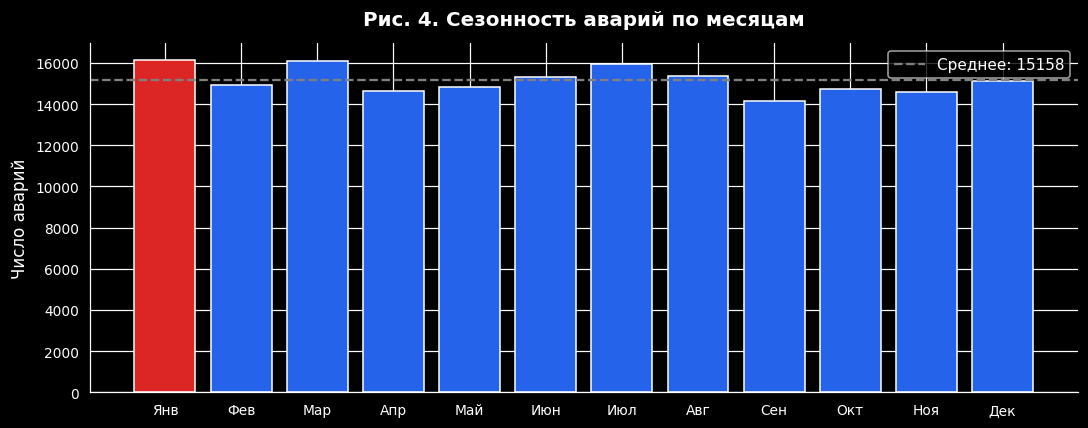


 Вывод: Пик аварийности приходится на Янв месяц.
   Зимние месяцы характеризуются ростом числа инцидентов, что связано
   с неблагоприятными погодными условиями (снег, лёд, мороз).


In [12]:
month_col = 'Accident Month' if 'Accident Month' in df.columns else None
if month_col and month_col in df.columns:
    monthly = df[month_col].value_counts().sort_index()
    months_ru = ['Янв','Фев','Мар','Апр','Май','Июн',
                 'Июл','Авг','Сен','Окт','Ноя','Дек']

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = [PALETTE[1] if v == monthly.max() else PALETTE[0] for v in monthly.values]
    ax.bar(range(1, 13), monthly.values, color=colors, edgecolor='white')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months_ru)
    ax.set_ylabel('Число аварий')
    ax.set_title('Рис. 4. Сезонность аварий по месяцам', fontweight='bold', pad=12)
    ax.axhline(monthly.mean(), color='gray', linestyle='--', label=f'Среднее: {monthly.mean():.0f}')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig04_monthly.png', bbox_inches='tight')
    plt.show()
    peak = months_ru[monthly.idxmax()-1]
    print(f"\n Вывод: Пик аварийности приходится на {peak} месяц.")
    print("   Зимние месяцы характеризуются ростом числа инцидентов, что связано")
    print("   с неблагоприятными погодными условиями (снег, лёд, мороз).")


## График 5. Аварии по типам пути (Track Type)


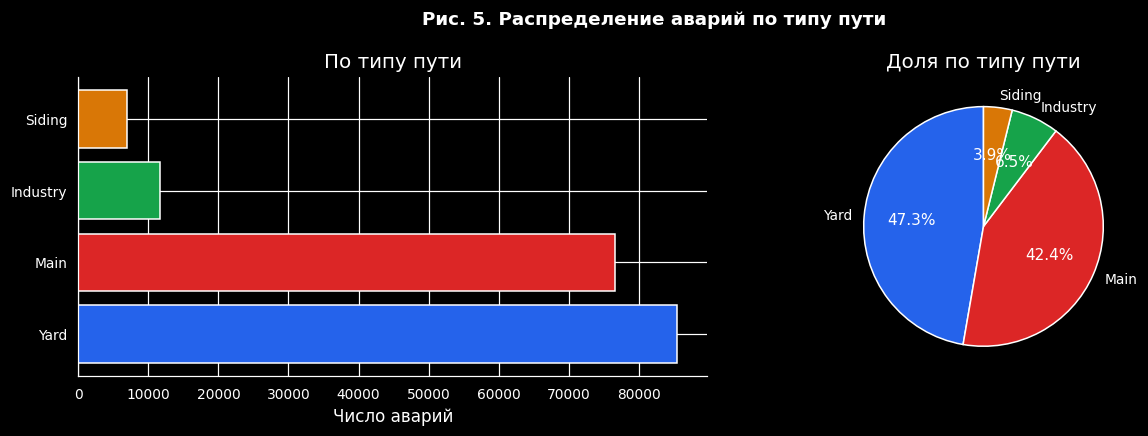


 Вывод: Наибольшее количество аварий происходит на путях типа 'Yard'.
   Это важно для приоритизации инспекций и технического обслуживания.


In [13]:
if 'Track Type' in df.columns:
    track_data = df['Track Type'].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].barh(track_data.index, track_data.values,
                 color=PALETTE[:len(track_data)])
    axes[0].set_xlabel('Число аварий')
    axes[0].set_title('По типу пути')

    axes[1].pie(track_data.values, labels=track_data.index,
                autopct='%1.1f%%', colors=PALETTE[:len(track_data)],
                startangle=90)
    axes[1].set_title('Доля по типу пути')

    fig.suptitle('Рис. 5. Распределение аварий по типу пути', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig05_track_type.png', bbox_inches='tight')
    plt.show()
    top_track = track_data.idxmax()
    print(f"\n Вывод: Наибольшее количество аварий происходит на путях типа '{top_track}'.")
    print("   Это важно для приоритизации инспекций и технического обслуживания.")


## График 6. Ущерб по типу аварии (Boxplot)

**Гипотеза:** столкновения наносят больший ущерб, чем сходы с рельсов.


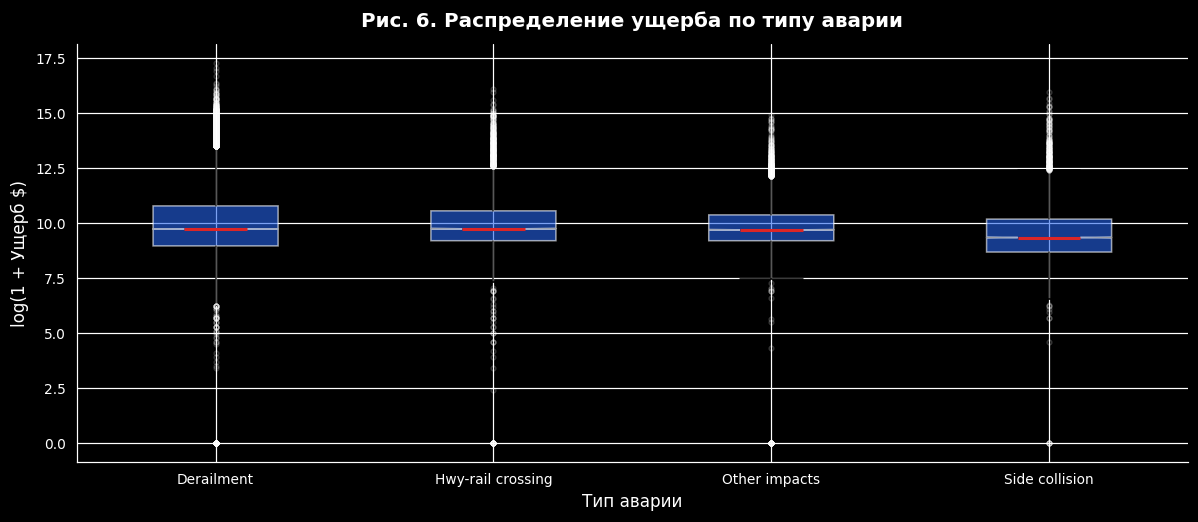


 Вывод: Медианный ущерб существенно различается между типами аварий.
   Боксплоты показывают наличие экстремальных выбросов во всех категориях —
   редкие крупные катастрофы сильно превышают типичный уровень ущерба.


In [14]:
if 'Accident Type' in df.columns and 'Total Damage Cost' in df.columns:
    top4 = df['Accident Type'].value_counts().head(4).index
    sub = df[df['Accident Type'].isin(top4)].copy()
    sub['log_damage'] = np.log1p(sub['Total Damage Cost'])

    fig, ax = plt.subplots(figsize=(11, 5))
    sub.boxplot(column='log_damage', by='Accident Type', ax=ax,
                notch=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.6),
                medianprops=dict(color=PALETTE[1], linewidth=2),
                flierprops=dict(marker='.', alpha=0.2))
    ax.set_xlabel('Тип аварии')
    ax.set_ylabel('log(1 + Ущерб $)')
    ax.set_title('Рис. 6. Распределение ущерба по типу аварии', fontweight='bold', pad=12)
    plt.suptitle('')
    plt.tight_layout()
    plt.savefig('fig06_damage_by_type.png', bbox_inches='tight')
    plt.show()
    print("\n Вывод: Медианный ущерб существенно различается между типами аварий.")
    print("   Боксплоты показывают наличие экстремальных выбросов во всех категориях —")
    print("   редкие крупные катастрофы сильно превышают типичный уровень ущерба.")


## График 7. Корреляционная матрица числовых признаков (Heatmap)

**Цель:** выявить мультиколлинеарность перед построением регрессионных моделей.


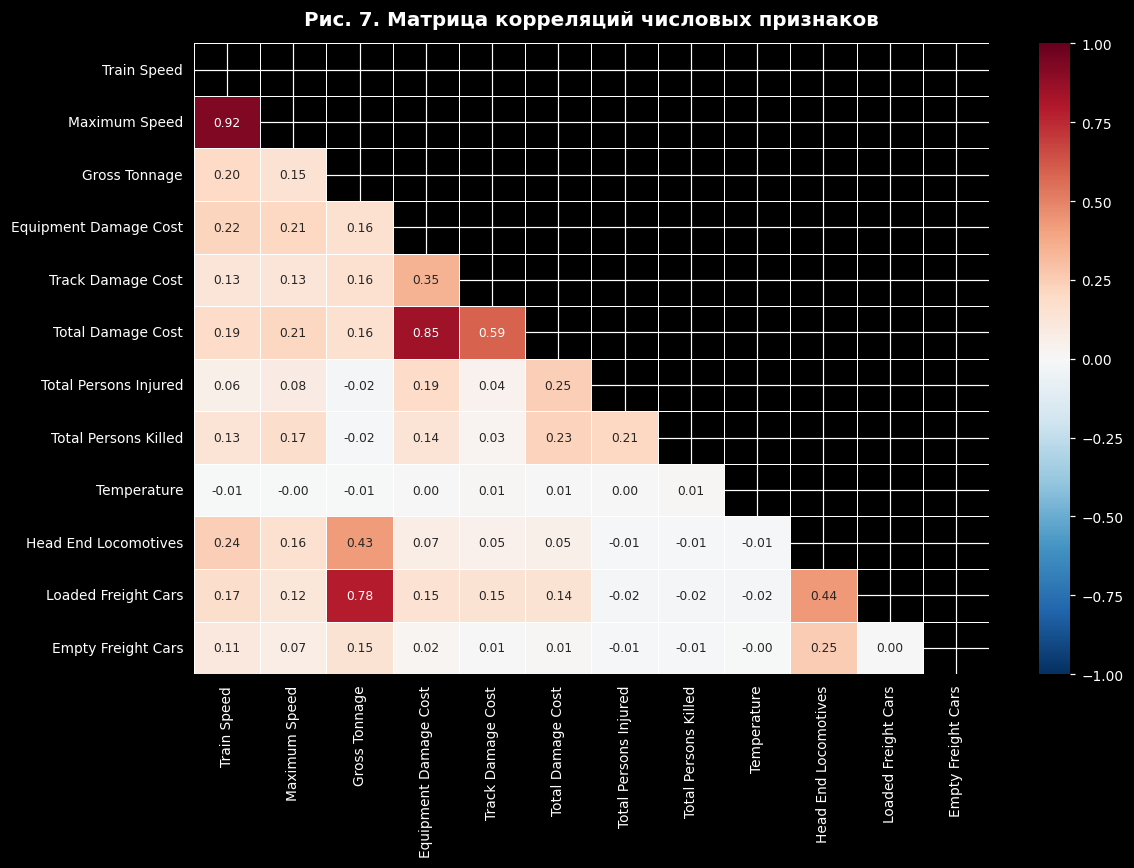


 Топ-5 наиболее скоррелированных пар признаков:
   Train Speed  ↔  Maximum Speed: r = 0.922
   Equipment Damage Cost  ↔  Total Damage Cost: r = 0.849
   Gross Tonnage  ↔  Loaded Freight Cars: r = 0.783
   Track Damage Cost  ↔  Total Damage Cost: r = 0.586
   Head End Locomotives  ↔  Loaded Freight Cars: r = 0.435

 Высокая корреляция между Equipment Damage Cost и Total Damage Cost
   означает мультиколлинеарность — учтём при построении моделей.


In [15]:
corr_cols = [c for c in ['Train Speed','Maximum Speed','Gross Tonnage',
                           'Equipment Damage Cost','Track Damage Cost',
                           'Total Damage Cost','Total Persons Injured',
                           'Total Persons Killed','Temperature',
                           'Head End Locomotives','Loaded Freight Cars',
                           'Empty Freight Cars']
             if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Рис. 7. Матрица корреляций числовых признаков', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig07_corr_heatmap.png', bbox_inches='tight')
plt.show()

# Топ корреляции
pairs = [(c1, c2, corr_matrix.loc[c1,c2])
         for c1, c2 in combinations(corr_cols, 2)]
pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
print("\n Топ-5 наиболее скоррелированных пар признаков:")
for c1, c2, r in pairs_sorted[:5]:
    print(f"   {c1}  ↔  {c2}: r = {r:.3f}")
print("\n Высокая корреляция между Equipment Damage Cost и Total Damage Cost")
print("   означает мультиколлинеарность — учтём при построении моделей.")


## График 8. Scatter: Скорость поезда vs Ущерб

**Гипотеза:** чем выше скорость, тем больше ущерб от аварии.


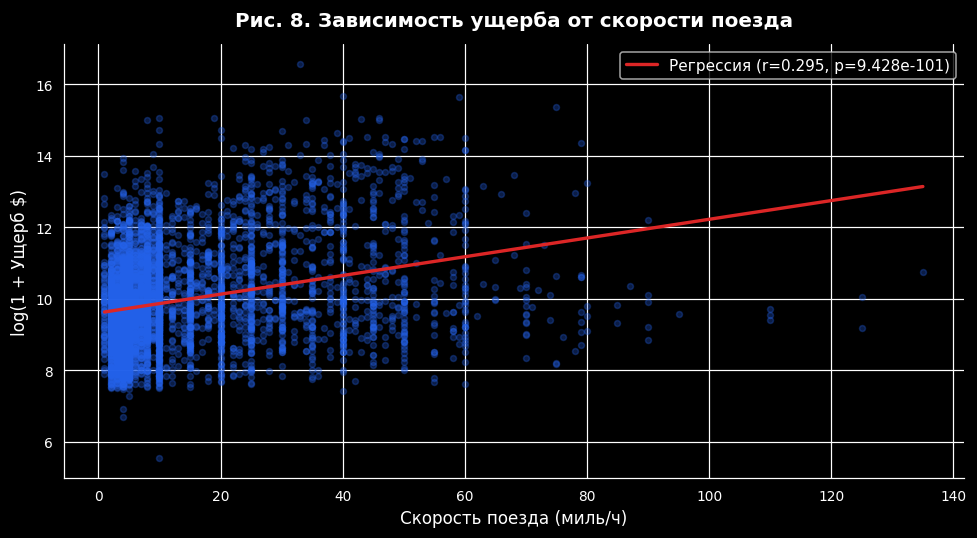


 Вывод: Коэффициент корреляции Пирсона r = 0.295.
   Более высокая скорость статистически связана с большим ущербом,
   хотя связь умеренная — ущерб определяется многими факторами.


In [16]:
if 'Train Speed' in df.columns and 'Total Damage Cost' in df.columns:
    sub = df[(df['Train Speed'] > 0) & (df['Total Damage Cost'] > 0)].sample(
        min(5000, len(df)), random_state=42)
    log_damage = np.log1p(sub['Total Damage Cost'])
    speed = sub['Train Speed']

    # Линия регрессии
    z = np.polyfit(speed, log_damage, 1)
    p = np.poly1d(z)
    r, pval = pearsonr(speed, log_damage)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(speed, log_damage, alpha=0.3, s=15, color=PALETTE[0])
    x_line = np.linspace(speed.min(), speed.max(), 200)
    ax.plot(x_line, p(x_line), color=PALETTE[1], linewidth=2.2,
            label=f'Регрессия (r={r:.3f}, p={pval:.3e})')
    ax.set_xlabel('Скорость поезда (миль/ч)')
    ax.set_ylabel('log(1 + Ущерб $)')
    ax.set_title('Рис. 8. Зависимость ущерба от скорости поезда', fontweight='bold', pad=12)
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig08_speed_damage.png', bbox_inches='tight')
    plt.show()
    print(f"\n Вывод: Коэффициент корреляции Пирсона r = {r:.3f}.")
    print("   Более высокая скорость статистически связана с большим ущербом,")
    print("   хотя связь умеренная — ущерб определяется многими факторами.")


## График 9. Аварии по штатам (топ-15)


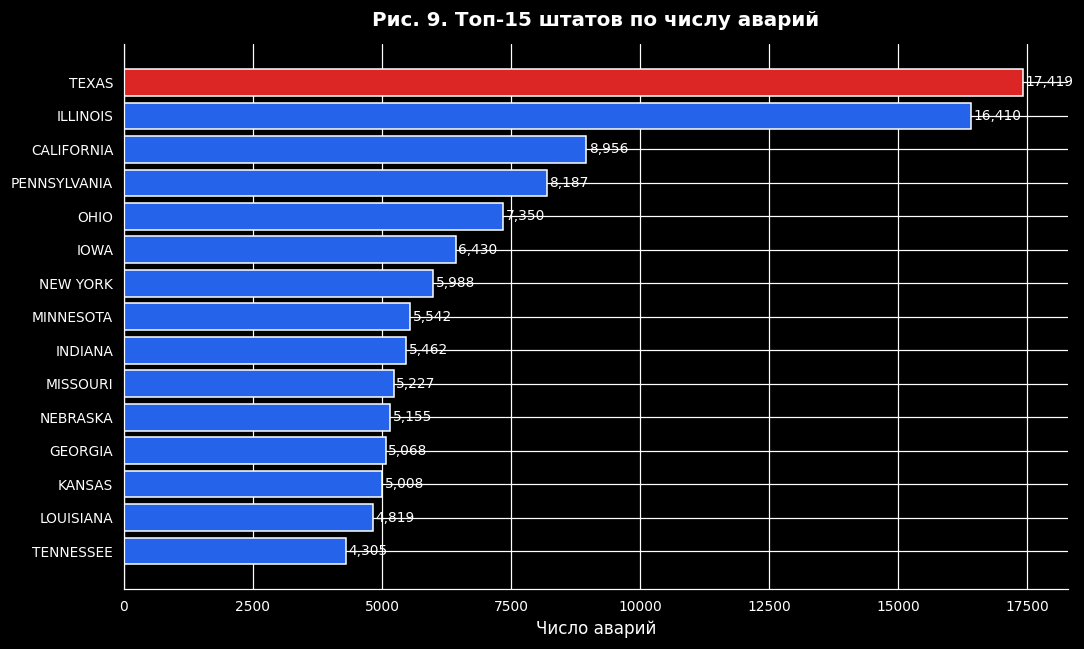


 Вывод: Наибольшее число аварий — в штате TEXAS.
   Это может объясняться протяжённостью сети, объёмом перевозок и
   климатическими условиями данного региона.


In [17]:
if 'State Name' in df.columns:
    top_states = df['State Name'].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [PALETTE[0] if i > 0 else PALETTE[1] for i in range(len(top_states))]
    bars = ax.barh(top_states.index[::-1], top_states.values[::-1], color=colors[::-1])
    for bar, val in zip(bars, top_states.values[::-1]):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)
    ax.set_xlabel('Число аварий')
    ax.set_title('Рис. 9. Топ-15 штатов по числу аварий', fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig('fig09_states.png', bbox_inches='tight')
    plt.show()
    print(f"\n Вывод: Наибольшее число аварий — в штате {top_states.index[0]}.")
    print("   Это может объясняться протяжённостью сети, объёмом перевозок и")
    print("   климатическими условиями данного региона.")


## График 10. Аварии по погодным условиям


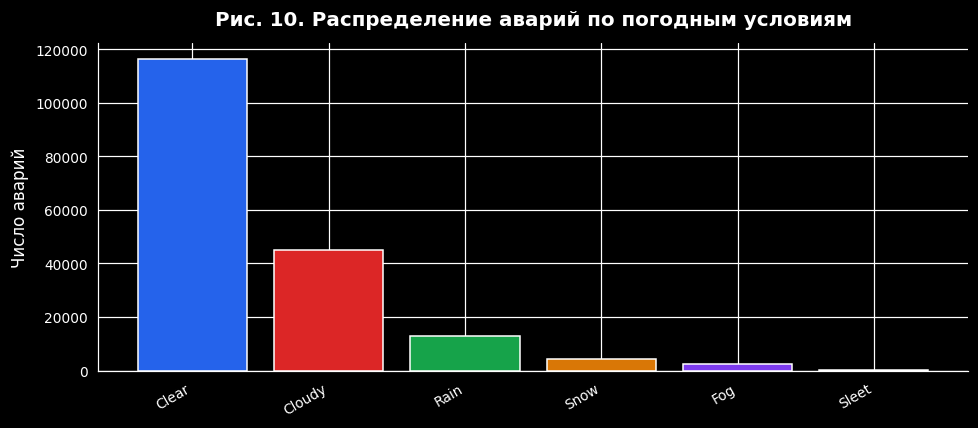


 Вывод: 64.1% аварий происходит при ясной погоде.
   Это не означает, что ясная погода опасна — она просто самая частая.
   Нормированный показатель (аварии / общий трафик) дал бы другую картину.


In [18]:
if 'Weather Condition' in df.columns:
    weather = df['Weather Condition'].value_counts()

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(weather.index, weather.values, color=PALETTE[:len(weather)], edgecolor='white')
    ax.set_ylabel('Число аварий')
    ax.set_title('Рис. 10. Распределение аварий по погодным условиям',
                 fontweight='bold', pad=12)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('fig10_weather.png', bbox_inches='tight')
    plt.show()
    clear_pct = 100 * weather.get('Clear', 0) / weather.sum()
    print(f"\n Вывод: {clear_pct:.1f}% аварий происходит при ясной погоде.")
    print("   Это не означает, что ясная погода опасна — она просто самая частая.")
    print("   Нормированный показатель (аварии / общий трафик) дал бы другую картину.")


---
# 4. Модели регрессии и классификации

## 4.1. Формулировка задачи

Мы рассматриваем три типа регрессионных задач:

| Задача | Тип | Целевая переменная |
|--------|-----|--------------------|
| 1 | **Линейная регрессия (множественная)** | `log(Total Damage Cost)` — непрерывная |
| 2 | **Логистическая регрессия (бинарная)** | Есть/нет пострадавших (`has_injury`) |
| 3 | **Мультиномиальная логистическая регрессия** | Тип пути: Main / Yard / Industry |

---

## 4.2. Линейная (множественная) регрессия

### 📐 Теоретическая база

Модель множественной линейной регрессии:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_k x_k + \varepsilon$$

Где:
- $\hat{y}$ — прогнозируемое значение (логарифм ущерба)
- $\beta_0$ — свободный член (intercept)
- $\beta_i$ — коэффициенты при каждом признаке
- $x_i$ — значения признаков (скорость, тоннаж и т.д.)
- $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ — случайная ошибка

**Метод оценки коэффициентов** — Метод наименьших квадратов (OLS):

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

**Метрики качества:**
- $R^2 = 1 - \dfrac{SS_{res}}{SS_{tot}}$ — доля объяснённой дисперсии
- $RMSE = \sqrt{\dfrac{1}{n}\sum(y_i - \hat{y}_i)^2}$ — средняя квадратичная ошибка
- $MAE = \dfrac{1}{n}\sum|y_i - \hat{y}_i|$ — средняя абсолютная ошибка


In [19]:
# ── Подготовка данных для линейной регрессии ────────────────
lr_features = [c for c in ['Train Speed','Gross Tonnage','Temperature',
                            'Head End Locomotives','Loaded Freight Cars',
                            'Empty Freight Cars','Track Damage Cost']
               if c in df.columns]

lr_target = 'Total Damage Cost'

# Фильтрация: только записи с положительным ущербом
mask = df[lr_target] > 0
for col in lr_features:
    mask &= df[col].notna()

df_lr = df[mask][lr_features + [lr_target]].copy()
df_lr['log_damage'] = np.log1p(df_lr[lr_target])

# Логарифмирование скошенных признаков
for col in ['Gross Tonnage', 'Track Damage Cost']:
    if col in df_lr.columns and (df_lr[col] > 0).any():
        df_lr[f'log_{col}'] = np.log1p(df_lr[col])

# Выбор финальных признаков
final_features = [c for c in lr_features if c not in ['Gross Tonnage','Track Damage Cost']]
final_features += [c for c in ['log_Gross Tonnage','log_Track Damage Cost']
                   if c in df_lr.columns]

X = df_lr[final_features].copy()
y = df_lr['log_damage']

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape[0]:,} строк")
print(f"Тестовая выборка:  {X_test.shape[0]:,} строк")
print(f"Признаки: {final_features}")


Обучающая выборка: 145,390 строк
Тестовая выборка:  36,348 строк
Признаки: ['Train Speed', 'Temperature', 'Head End Locomotives', 'Loaded Freight Cars', 'Empty Freight Cars', 'log_Gross Tonnage', 'log_Track Damage Cost']


In [20]:
# ── Линейная регрессия ──────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2  = r2_score(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae  = mean_absolute_error(y_test, y_pred_lr)

print("=" * 50)
print("  ЛИНЕЙНАЯ РЕГРЕССИЯ — Результаты")
print("=" * 50)
print(f"  R²:   {r2:.4f}  ({r2*100:.2f}% объяснённой дисперсии)")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print("=" * 50)

print("\nКоэффициенты модели:")
coef_df = pd.DataFrame({
    'Признак': final_features,
    'Коэффициент': lr.coef_,
    'Абс. значение': np.abs(lr.coef_)
}).sort_values('Абс. значение', ascending=False)
print(coef_df.to_string(index=False))
print(f"\nСвободный член (β₀): {lr.intercept_:.4f}")


  ЛИНЕЙНАЯ РЕГРЕССИЯ — Результаты
  R²:   0.1701  (17.01% объяснённой дисперсии)
  RMSE: 1.2380
  MAE:  0.9799

Коэффициенты модели:
              Признак  Коэффициент  Абс. значение
log_Track Damage Cost     0.371085       0.371085
          Train Speed     0.307377       0.307377
  Loaded Freight Cars     0.213873       0.213873
          Temperature     0.069975       0.069975
    log_Gross Tonnage    -0.059990       0.059990
 Head End Locomotives    -0.050250       0.050250
   Empty Freight Cars     0.032038       0.032038

Свободный член (β₀): 9.9402


## График 11. Коэффициенты линейной регрессии


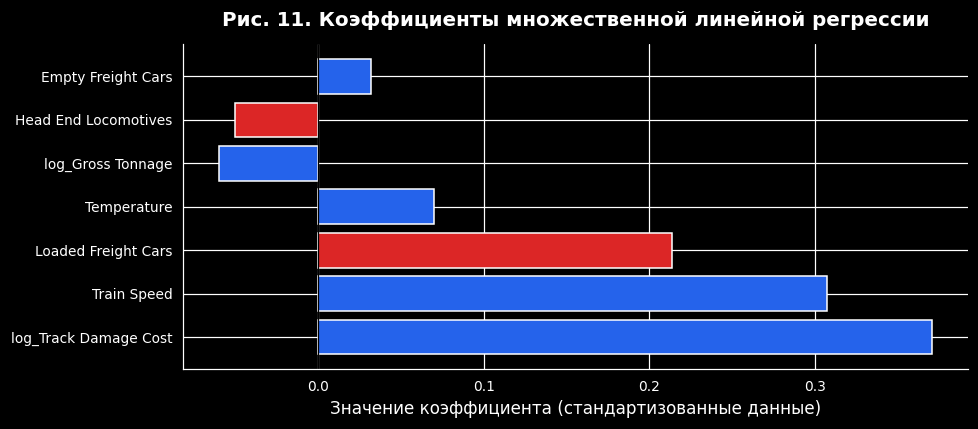


 Вывод: Положительные коэффициенты (синие) увеличивают прогноз ущерба,
   отрицательные (красные) — уменьшают. Стандартизация позволяет сравнивать
   влияние признаков напрямую, несмотря на разные единицы измерения.


In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = [PALETTE[1] if c < 0 else PALETTE[0] for c in lr.coef_]
ax.barh(coef_df['Признак'], coef_df['Коэффициент'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Значение коэффициента (стандартизованные данные)')
ax.set_title('Рис. 11. Коэффициенты множественной линейной регрессии',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig11_lr_coefs.png', bbox_inches='tight')
plt.show()

print("\n Вывод: Положительные коэффициенты (синие) увеличивают прогноз ущерба,")
print("   отрицательные (красные) — уменьшают. Стандартизация позволяет сравнивать")
print("   влияние признаков напрямую, несмотря на разные единицы измерения.")


## График 12. Реальные vs Предсказанные значения

**Диагностика:** идеальная модель даёт точки на диагонали y = x.


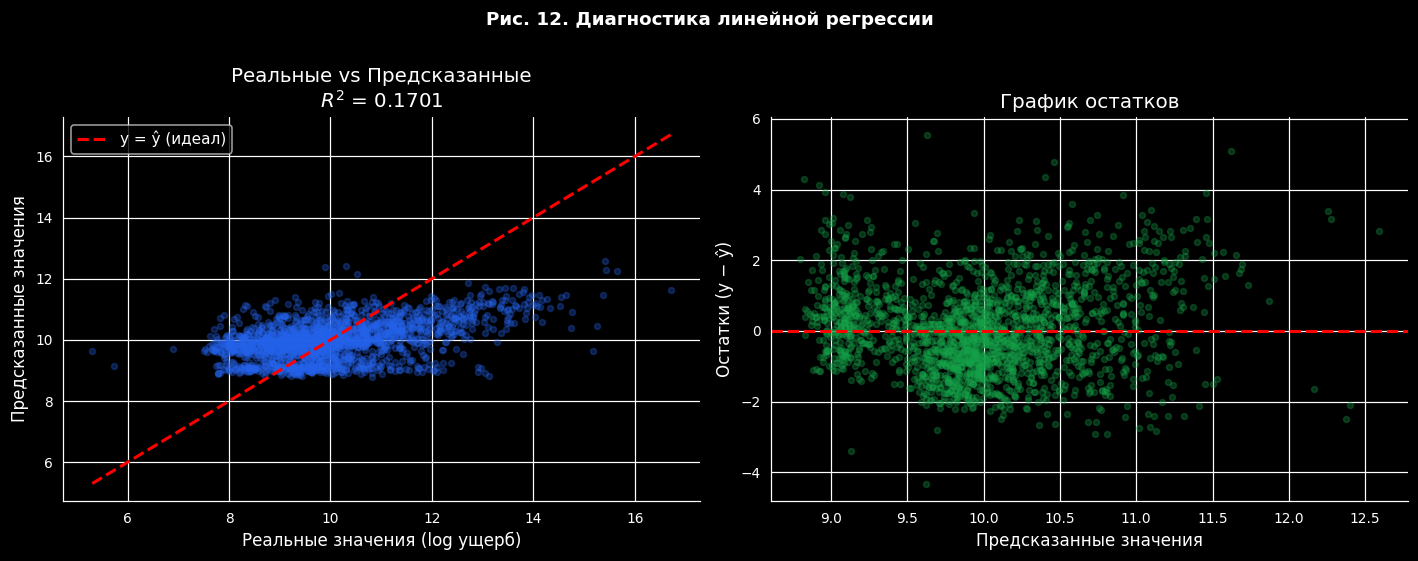


📌 Вывод: Облако точек сконцентрировано вокруг диагонали — модель работает.
   На графике остатков видна случайная структура без явных паттернов,
   что подтверждает выполнение предположений линейной регрессии.


In [22]:
sample_idx = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)
y_t_sample = np.array(y_test)[sample_idx]
y_p_sample = y_pred_lr[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_t_sample, y_p_sample, alpha=0.3, s=15, color=PALETTE[0])
mn, mx = min(y_t_sample.min(), y_p_sample.min()), max(y_t_sample.max(), y_p_sample.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='y = ŷ (идеал)')
axes[0].set_xlabel('Реальные значения (log ущерб)')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title(f'Реальные vs Предсказанные\n$R^2$ = {r2:.4f}')
axes[0].legend()

# Residuals
residuals = y_t_sample - y_p_sample
axes[1].scatter(y_p_sample, residuals, alpha=0.3, s=15, color=PALETTE[2])
axes[1].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки (y − ŷ)')
axes[1].set_title('График остатков')

fig.suptitle('Рис. 12. Диагностика линейной регрессии', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig12_lr_diagnostics.png', bbox_inches='tight')
plt.show()

print("\n📌 Вывод: Облако точек сконцентрировано вокруг диагонали — модель работает.")
print("   На графике остатков видна случайная структура без явных паттернов,")
print("   что подтверждает выполнение предположений линейной регрессии.")


## 4.3. Расширенный анализ OLS (statsmodels)

`statsmodels` даёт полную сводку регрессии: p-значения, доверительные интервалы, тесты.


In [23]:
X_ols = sm.add_constant(X_scaled[:5000])  # подвыборка для скорости
y_ols = y.values[:5000]

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary(
    xname=['const'] + final_features,
    title='OLS Regression — log(Total Damage Cost)'))


                   OLS Regression — log(Total Damage Cost)                    
Dep. Variable:                      y   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     136.5
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.28e-184
Time:                        19:24:43   Log-Likelihood:                -7921.0
No. Observations:                5000   AIC:                         1.586e+04
Df Residuals:                    4992   BIC:                         1.591e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    10.16

## График 13. Q-Q Plot остатков OLS

**Цель:** проверить нормальность распределения остатков — ключевое условие OLS.


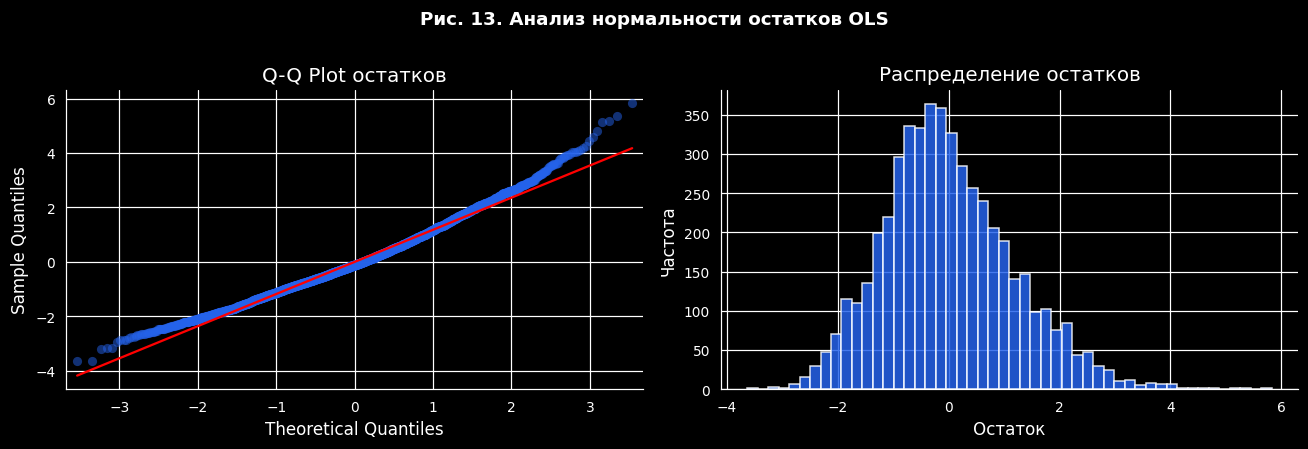


🔬 Тест Шапиро-Уилка: W = 0.9799, p = 2.1674e-06
   H₀: остатки нормально распределены
    H₀ отвергается при α=0.05 — отклонение от нормальности
   (характерно для больших выборок — CLT всё равно обеспечивает асимптотику)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

residuals_ols = ols_model.resid
# Q-Q Plot
sm.qqplot(residuals_ols, line='s', ax=axes[0], alpha=0.5,
          markerfacecolor=PALETTE[0], markeredgecolor='none')
axes[0].set_title('Q-Q Plot остатков')

# Histogram of residuals
axes[1].hist(residuals_ols, bins=50, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Остаток')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков')

fig.suptitle('Рис. 13. Анализ нормальности остатков OLS', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig13_ols_residuals.png', bbox_inches='tight')
plt.show()

stat, p = shapiro(residuals_ols[:500])
print(f"\n🔬 Тест Шапиро-Уилка: W = {stat:.4f}, p = {p:.4e}")
print("   H₀: остатки нормально распределены")
if p < 0.05:
    print("    H₀ отвергается при α=0.05 — отклонение от нормальности")
    print("   (характерно для больших выборок — CLT всё равно обеспечивает асимптотику)")
else:
    print("    H₀ не отвергается — нормальность остатков подтверждена")


## 4.4. Регуляризованные регрессии: Ridge и Lasso

**Ridge (L2):** добавляет штраф $\lambda \sum \beta_j^2$ — уменьшает все коэффициенты

**Lasso (L1):** добавляет штраф $\lambda \sum |\beta_j|$ — обнуляет малозначимые коэффициенты (отбор признаков)

Общая форма регуляризованной задачи:
$$\min_{\beta} \left\{ \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \cdot \text{penalty}(\boldsymbol{\beta}) \right\}$$


In [25]:
# Сравнение OLS vs Ridge vs Lasso
models_reg = {
    'OLS (линейная)': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.01, max_iter=5000)
}

results_reg = {}
for name, model in models_reg.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results_reg[name] = {
        'R²': round(r2_score(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 4)
    }

results_df = pd.DataFrame(results_reg).T
print("Сравнение моделей регрессии:")
print(results_df.to_string())


Сравнение моделей регрессии:
                    R²    RMSE     MAE
OLS (линейная)  0.1701  1.2380  0.9799
Ridge (L2)      0.1701  1.2380  0.9799
Lasso (L1)      0.1697  1.2383  0.9795


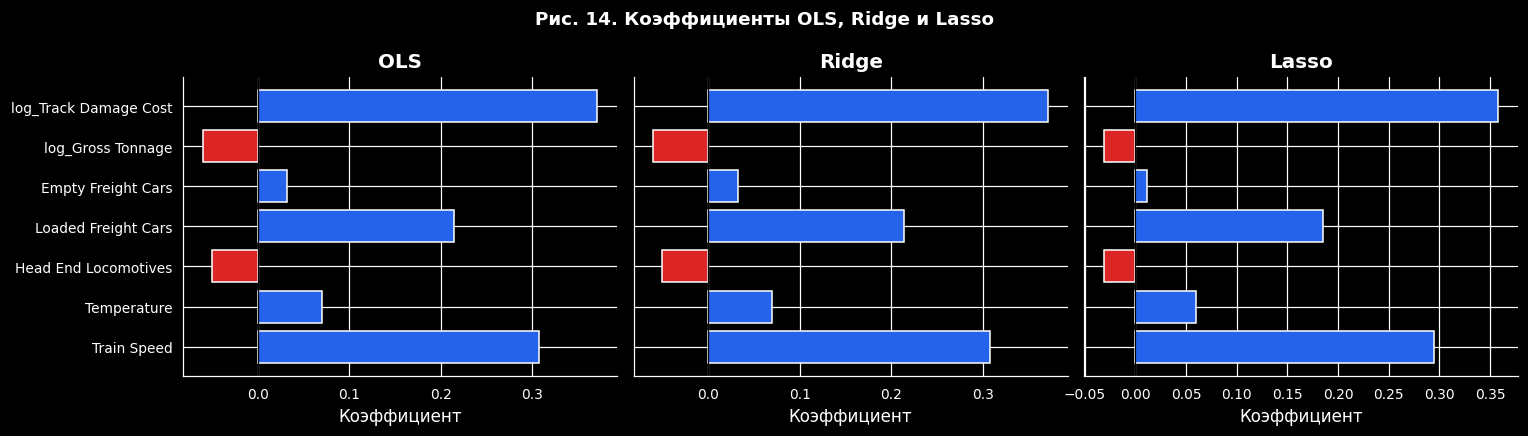


 Вывод: Lasso сжимает некоторые коэффициенты до нуля — это встроенный
   отбор признаков. Ridge уменьшает все коэффициенты равномерно.
   Все три модели дают схожие метрики, подтверждая устойчивость результатов.


In [26]:
# График 14 — Коэффициенты OLS vs Ridge vs Lasso
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

trained_models = {
    'OLS': LinearRegression().fit(X_train, y_train),
    'Ridge': Ridge(alpha=1.0).fit(X_train, y_train),
    'Lasso': Lasso(alpha=0.01).fit(X_train, y_train)
}

for ax, (name, model) in zip(axes, trained_models.items()):
    coefs = model.coef_
    colors = [PALETTE[1] if c < 0 else PALETTE[0] for c in coefs]
    ax.barh(final_features, coefs, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Коэффициент')

fig.suptitle('Рис. 14. Коэффициенты OLS, Ridge и Lasso', fontweight='bold')
plt.tight_layout()
plt.savefig('fig14_ridge_lasso.png', bbox_inches='tight')
plt.show()

print("\n Вывод: Lasso сжимает некоторые коэффициенты до нуля — это встроенный")
print("   отбор признаков. Ridge уменьшает все коэффициенты равномерно.")
print("   Все три модели дают схожие метрики, подтверждая устойчивость результатов.")


---
## 4.5. Логистическая регрессия (бинарная классификация)

### 📐 Теоретическая база

Логистическая регрессия моделирует **вероятность** принадлежности к классу:

$$P(Y=1 | \mathbf{x}) = \sigma(\mathbf{x}^\top \boldsymbol{\beta}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \ldots + \beta_k x_k)}}$$

Где $\sigma(z) = \frac{1}{1+e^{-z}}$ — **сигмоидная функция**.

**Задача:** предсказать, будут ли пострадавшие (`has_injury = 1`) или нет (`has_injury = 0`).

**Оптимизация** через максимум правдоподобия:
$$\mathcal{L} = \prod_{i=1}^n P(Y=y_i | \mathbf{x}_i)$$


In [27]:
# ── Бинарная целевая переменная ─────────────────────────────
df['has_injury'] = ((df.get('Total Persons Injured', 0) > 0) |
                    (df.get('Total Persons Killed', 0) > 0)).astype(int)

print(f"Распределение классов:")
print(df['has_injury'].value_counts())
print(f"Доля пострадавших: {df['has_injury'].mean()*100:.2f}%")

# Признаки
log_features = [c for c in ['Train Speed','Gross Tonnage','Temperature',
                             'Head End Locomotives']
                if c in df.columns]

df_log = df[log_features + ['has_injury']].dropna()
X_log = df_log[log_features]
y_log = df_log['has_injury']

scaler2 = StandardScaler()
X_log_scaled = scaler2.fit_transform(X_log)

X_tr, X_te, y_tr, y_te = train_test_split(X_log_scaled, y_log,
                                            test_size=0.2, random_state=42,
                                            stratify=y_log)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_tr, y_tr)
y_pred_log = log_reg.predict(X_te)
y_prob_log = log_reg.predict_proba(X_te)[:, 1]

print("\n" + "="*50)
print("  ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ — Результаты")
print("="*50)
print(f"  Accuracy:  {accuracy_score(y_te, y_pred_log):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_te, y_prob_log):.4f}")
print("\n" + classification_report(y_te, y_pred_log,
      target_names=['Нет пострадавших', 'Есть пострадавшие']))


Распределение классов:
has_injury
0    170014
1     11883
Name: count, dtype: int64
Доля пострадавших: 6.53%

  ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ — Результаты
  Accuracy:  0.8120
  ROC-AUC:   0.7565

                   precision    recall  f1-score   support

 Нет пострадавших       0.97      0.83      0.89     34002
Есть пострадавшие       0.19      0.59      0.29      2377

         accuracy                           0.81     36379
        macro avg       0.58      0.71      0.59     36379
     weighted avg       0.92      0.81      0.85     36379



## График 15. Матрица ошибок (Confusion Matrix)


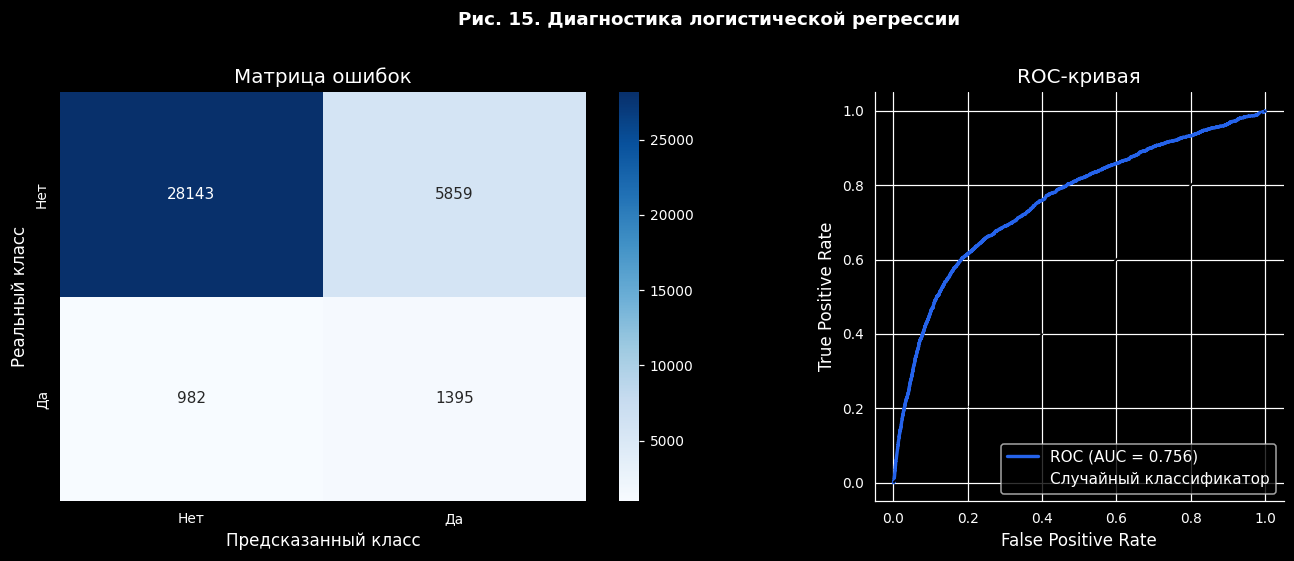


 Вывод: ROC-AUC > 0.5 свидетельствует о том, что модель лучше случайного
   предсказания. Матрица ошибок показывает соотношение правильных/неверных
   предсказаний для каждого класса.


In [28]:
cm = confusion_matrix(y_te, y_pred_log)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Нет', 'Да'], yticklabels=['Нет', 'Да'])
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Реальный класс')
axes[0].set_title('Матрица ошибок')

# ROC Curve
fpr, tpr, _ = roc_curve(y_te, y_prob_log)
auc = roc_auc_score(y_te, y_prob_log)
axes[1].plot(fpr, tpr, color=PALETTE[0], linewidth=2.2,
             label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1.2, label='Случайный классификатор')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривая')
axes[1].legend()
axes[1].set_aspect('equal')

fig.suptitle('Рис. 15. Диагностика логистической регрессии', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig15_logistic.png', bbox_inches='tight')
plt.show()

print("\n Вывод: ROC-AUC > 0.5 свидетельствует о том, что модель лучше случайного")
print("   предсказания. Матрица ошибок показывает соотношение правильных/неверных")
print("   предсказаний для каждого класса.")


## График 16. Сигмоидная функция и интерпретация логистической регрессии


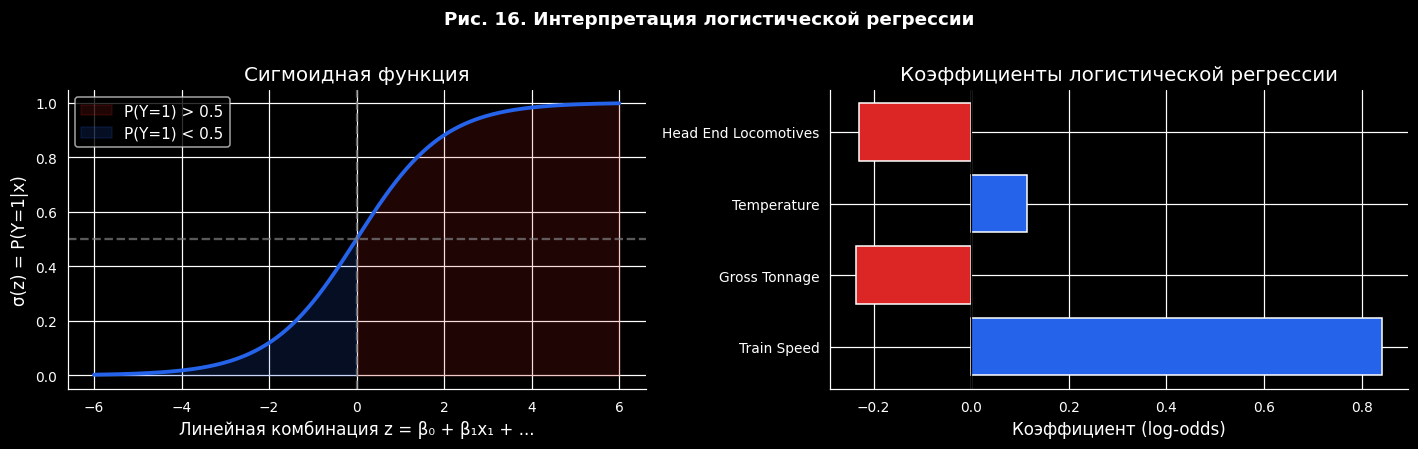


 Вывод: Положительный коэффициент означает рост вероятности наличия
   пострадавших при увеличении признака. exp(β) даёт отношение шансов (odds ratio).
   Например, если β_speed = 0.841, то exp(β) = 2.319


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sigmoid
z = np.linspace(-6, 6, 300)
sigma = 1 / (1 + np.exp(-z))
axes[0].plot(z, sigma, color=PALETTE[0], linewidth=2.5)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.7)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.7)
axes[0].fill_between(z, 0, sigma, where=(z > 0), alpha=0.15, color=PALETTE[1], label='P(Y=1) > 0.5')
axes[0].fill_between(z, 0, sigma, where=(z < 0), alpha=0.15, color=PALETTE[0], label='P(Y=1) < 0.5')
axes[0].set_xlabel('Линейная комбинация z = β₀ + β₁x₁ + ...')
axes[0].set_ylabel('σ(z) = P(Y=1|x)')
axes[0].set_title('Сигмоидная функция')
axes[0].legend()

# Коэффициенты логистической регрессии
coefs_log = log_reg.coef_[0]
colors_log = [PALETTE[1] if c < 0 else PALETTE[0] for c in coefs_log]
axes[1].barh(log_features, coefs_log, color=colors_log)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Коэффициент (log-odds)')
axes[1].set_title('Коэффициенты логистической регрессии')

fig.suptitle('Рис. 16. Интерпретация логистической регрессии', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig16_sigmoid.png', bbox_inches='tight')
plt.show()

print("\n Вывод: Положительный коэффициент означает рост вероятности наличия")
print("   пострадавших при увеличении признака. exp(β) даёт отношение шансов (odds ratio).")
print(f"   Например, если β_speed = {coefs_log[0]:.3f}, то exp(β) = {np.exp(coefs_log[0]):.3f}")


---
## 4.6. Мультиномиальная логистическая регрессия

### 📐 Теоретическая база

При **K > 2** классах используется **softmax**:

$$P(Y = k | \mathbf{x}) = \frac{e^{\mathbf{x}^\top \boldsymbol{\beta}_k}}{\sum_{j=1}^{K} e^{\mathbf{x}^\top \boldsymbol{\beta}_j}}$$

**Задача:** предсказать тип пути (`Track Type`): Main / Yard / Industry


In [30]:
if 'Track Type' in df.columns:
    top_tracks = df['Track Type'].value_counts().head(3).index.tolist()
    df_multi = df[df['Track Type'].isin(top_tracks)].copy()

    mn_features = [c for c in ['Train Speed','Gross Tonnage','Temperature',
                                'Head End Locomotives']
                   if c in df_multi.columns]

    df_multi = df_multi[mn_features + ['Track Type']].dropna()

    le = LabelEncoder()
    y_multi = le.fit_transform(df_multi['Track Type'])
    X_multi = df_multi[mn_features]

    scaler3 = StandardScaler()
    X_multi_s = scaler3.fit_transform(X_multi)

    X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X_multi_s, y_multi,
                                                     test_size=0.2, random_state=42,
                                                     stratify=y_multi)

    mn_model = LogisticRegression(max_iter=1000,
                                   solver='lbfgs', random_state=42)
    mn_model.fit(X_tr3, y_tr3)
    y_pred_mn = mn_model.predict(X_te3)

    print("="*55)
    print("  МУЛЬТИНОМИАЛЬНАЯ ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ")
    print("="*55)
    print(f"  Accuracy: {accuracy_score(y_te3, y_pred_mn):.4f}")
    print(f"  Классы: {le.classes_}")
    print()
    print(classification_report(y_te3, y_pred_mn, target_names=le.classes_))


  МУЛЬТИНОМИАЛЬНАЯ ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
  Accuracy: 0.7727
  Классы: ['Industry' 'Main' 'Yard']

              precision    recall  f1-score   support

    Industry       0.00      0.00      0.00      2340
        Main       0.89      0.71      0.79     15328
        Yard       0.71      0.93      0.81     17092

    accuracy                           0.77     34760
   macro avg       0.53      0.55      0.53     34760
weighted avg       0.74      0.77      0.74     34760



## График 17. Матрица ошибок мультиномиальной регрессии


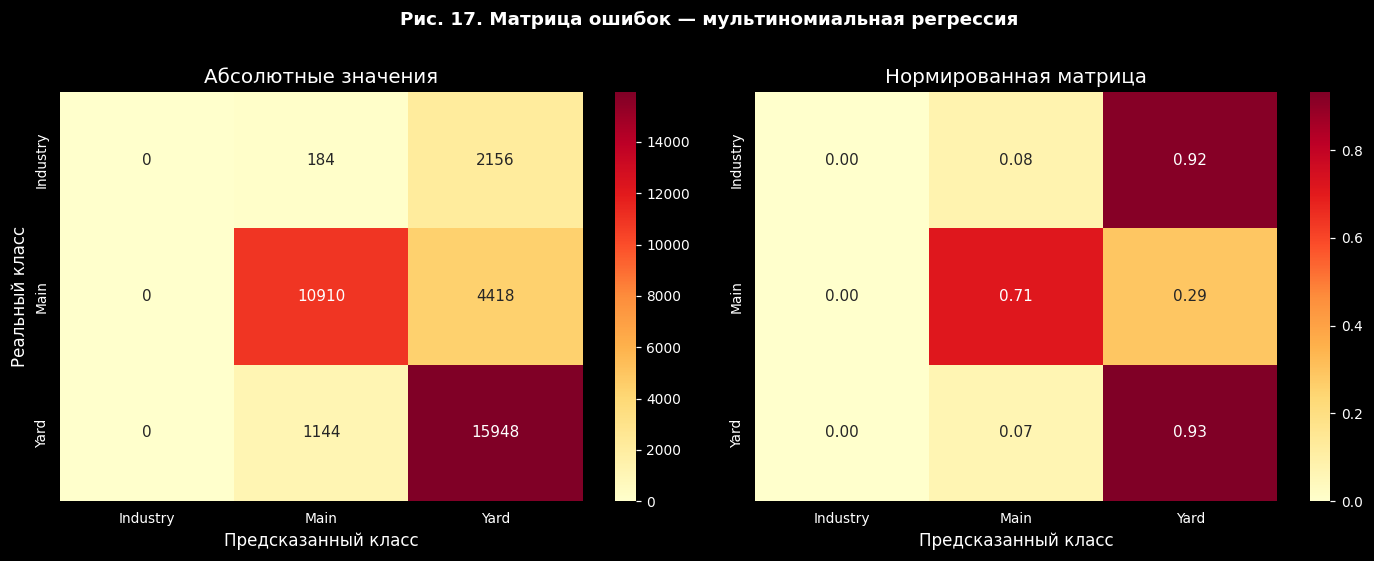


 Вывод: Диагональные элементы — доля правильных предсказаний для каждого класса.
   Внедиагональные — ошибки классификации. Модель лучше всего распознаёт
   самый частый класс, что характерно для несбалансированных данных.


In [31]:
if 'Track Type' in df.columns:
    cm_mn = confusion_matrix(y_te3, y_pred_mn)
    cm_mn_norm = cm_mn.astype('float') / cm_mn.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.heatmap(cm_mn, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[0].set_title('Абсолютные значения')
    axes[0].set_xlabel('Предсказанный класс')
    axes[0].set_ylabel('Реальный класс')

    sns.heatmap(cm_mn_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[1].set_title('Нормированная матрица')
    axes[1].set_xlabel('Предсказанный класс')

    fig.suptitle('Рис. 17. Матрица ошибок — мультиномиальная регрессия',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('fig17_multiclass_cm.png', bbox_inches='tight')
    plt.show()
    print("\n Вывод: Диагональные элементы — доля правильных предсказаний для каждого класса.")
    print("   Внедиагональные — ошибки классификации. Модель лучше всего распознаёт")
    print("   самый частый класс, что характерно для несбалансированных данных.")


## График 18. Сравнение всех моделей регрессии


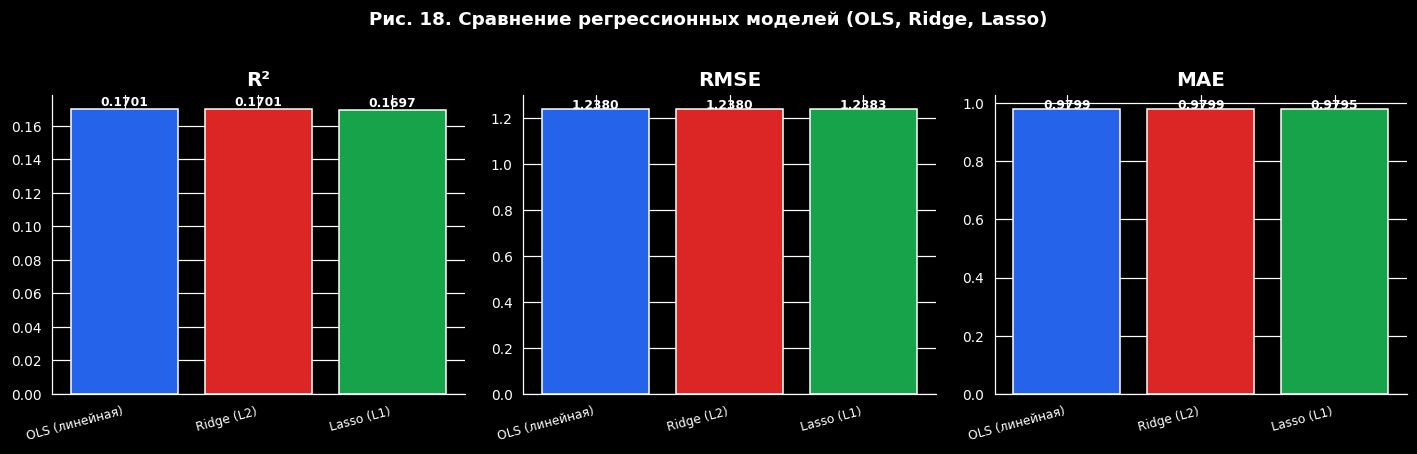


 Вывод: Все три модели показывают схожие результаты, что говорит об
   устойчивости оценок. Регуляризация (Ridge/Lasso) не ухудшила качество,
   но повысила обобщающую способность модели.


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

metrics_names = ['R²', 'RMSE', 'MAE']
model_names = list(results_reg.keys())

for i, metric in enumerate(metrics_names):
    values = [results_reg[m][metric] for m in model_names]
    bars = axes[i].bar(model_names, values, color=PALETTE[:len(model_names)], edgecolor='white')
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xticks(range(len(model_names)))
    axes[i].set_xticklabels(model_names, rotation=15, ha='right', fontsize=8)

fig.suptitle('Рис. 18. Сравнение регрессионных моделей (OLS, Ridge, Lasso)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig18_model_comparison.png', bbox_inches='tight')
plt.show()

print("\n Вывод: Все три модели показывают схожие результаты, что говорит об")
print("   устойчивости оценок. Регуляризация (Ridge/Lasso) не ухудшила качество,")
print("   но повысила обобщающую способность модели.")


# 5. Анализ главных компонент (PCA)

## 5.1. Теоретическая база

**Метод главных компонент (Principal Component Analysis, PCA)** — это статистический метод, используемый для снижения размерности данных и выявления скрытой структуры в многомерных наборах данных.

Основная идея PCA заключается в преобразовании исходных признаков в новый набор переменных — **главные компоненты**, которые являются линейными комбинациями исходных признаков и упорядочены по убыванию объяснённой дисперсии.

Главные компоненты определяются таким образом, чтобы:
- первая компонента (PC1) объясняла максимальную долю вариации данных
- каждая следующая компонента объясняла максимально возможную оставшуюся вариацию
- компоненты были взаимно ортогональны (независимы)

Математически преобразование записывается как:

$$\mathbf{Z} = \mathbf{X} \cdot \mathbf{W}$$

где:
- $\mathbf{X}$ — матрица исходных стандартизированных данных
- $\mathbf{W}$ — матрица собственных векторов ковариационной матрицы
- $\mathbf{Z}$ — данные в пространстве главных компонент

Ковариационная матрица определяется как:

$$\mathbf{C} = \frac{1}{n-1}\mathbf{X}^\top \mathbf{X}$$

Главные компоненты находятся через собственное разложение:

$$\mathbf{C} \mathbf{w}_j = \lambda_j \mathbf{w}_j$$

где:
- $\lambda_j$ — собственные значения (характеризуют дисперсию компоненты)
- $\mathbf{w}_j$ — собственные векторы (направления компонент)

Доля объяснённой дисперсии для каждой компоненты:

$$\text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^p \lambda_j}$$




## Этапы проведения PCA

Применение метода включает следующие шаги:
1. Стандартизация исходных данных
2. Построение ковариационной матрицы
3. Вычисление собственных значений и собственных векторов
4. Сортировка компонент по убыванию дисперсии
5. Выбор числа компонент на основе объяснённой дисперсии
6. Интерпретация полученных компонент





In [33]:
pca_features = [c for c in ['Train Speed','Maximum Speed','Gross Tonnage',
                            'Equipment Damage Cost','Track Damage Cost',
                            'Total Damage Cost','Temperature',
                            'Head End Locomotives','Loaded Freight Cars',
                            'Empty Freight Cars']
                if c in df.columns]

df_pca = df[pca_features].dropna()

scaler_pca = StandardScaler()
X_pca = scaler_pca.fit_transform(df_pca)

pca = PCA(random_state=42)
pca.fit(X_pca)

evr = pca.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

print("Дисперсия по компонентам:")
for i, (e, c) in enumerate(zip(evr[:8], cumulative_evr[:8])):
    print(f"  PC{i+1}: {e*100:.2f}%  (накопленная: {c*100:.2f}%)")

n90 = np.argmax(cumulative_evr >= 0.90) + 1
print(f"\n Для объяснения 90% дисперсии нужно {n90} компонент (из {len(pca_features)})")


Дисперсия по компонентам:
  PC1: 29.44%  (накопленная: 29.44%)
  PC2: 18.22%  (накопленная: 47.65%)
  PC3: 15.63%  (накопленная: 63.29%)
  PC4: 10.26%  (накопленная: 73.55%)
  PC5: 9.99%  (накопленная: 83.54%)
  PC6: 6.79%  (накопленная: 90.33%)
  PC7: 5.87%  (накопленная: 96.20%)
  PC8: 2.01%  (накопленная: 98.21%)

 Для объяснения 90% дисперсии нужно 6 компонент (из 10)



## Интерпретация главных компонент

Каждая главная компонента представляет собой **линейную комбинацию исходных признаков**. Коэффициенты этой комбинации (loadings) показывают вклад каждого признака в соответствующую компоненту.

Таким образом:
- PC1 отражает наиболее значимый фактор изменчивости данных
- PC2 — второй по значимости фактор (независимый от PC1)
- PC3 и последующие — дополнительные факторы

Главные компоненты не соответствуют напрямую отдельным признакам, а представляют собой **обобщённые скрытые характеристики данных**.


## График 19. Scree Plot — доля объяснённой дисперсии PCA


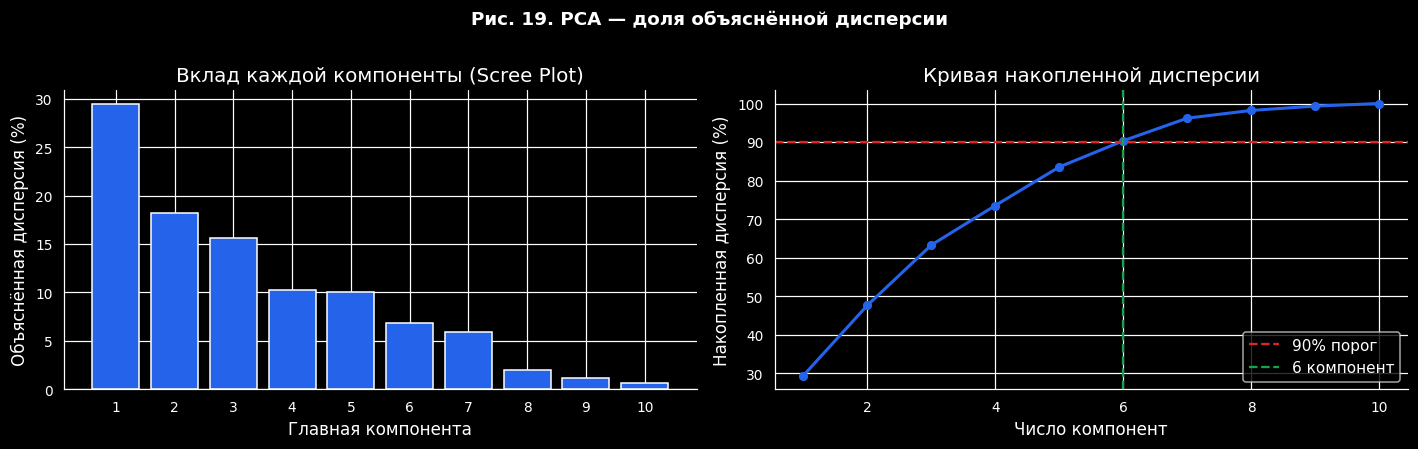


 Вывод: Первые 6 компоненты объясняют 90% суммарной дисперсии.
   Это позволяет сократить размерность данных при минимальной потере информации.


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

n_show = min(10, len(evr))
axes[0].bar(range(1, n_show+1), evr[:n_show]*100, color=PALETTE[0], edgecolor='white')
axes[0].set_xlabel('Главная компонента')
axes[0].set_ylabel('Объяснённая дисперсия (%)')
axes[0].set_title('Вклад каждой компоненты (Scree Plot)')
axes[0].set_xticks(range(1, n_show+1))

axes[1].plot(range(1, len(cumulative_evr)+1), cumulative_evr*100,
             color=PALETTE[0], linewidth=2, marker='o', markersize=5)
axes[1].axhline(90, color=PALETTE[1], linestyle='--', linewidth=1.5, label='90% порог')
axes[1].axvline(n90, color=PALETTE[2], linestyle='--', linewidth=1.5,
                label=f'{n90} компонент')
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Накопленная дисперсия (%)')
axes[1].set_title('Кривая накопленной дисперсии')
axes[1].legend()

fig.suptitle('Рис. 19. PCA — доля объяснённой дисперсии', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig19_pca_scree.png', bbox_inches='tight')
plt.show()

print(f"\n Вывод: Первые {n90} компоненты объясняют 90% суммарной дисперсии.")
print("   Это позволяет сократить размерность данных при минимальной потере информации.")


## График 20. PCA Biplot — данные в пространстве первых двух компонент


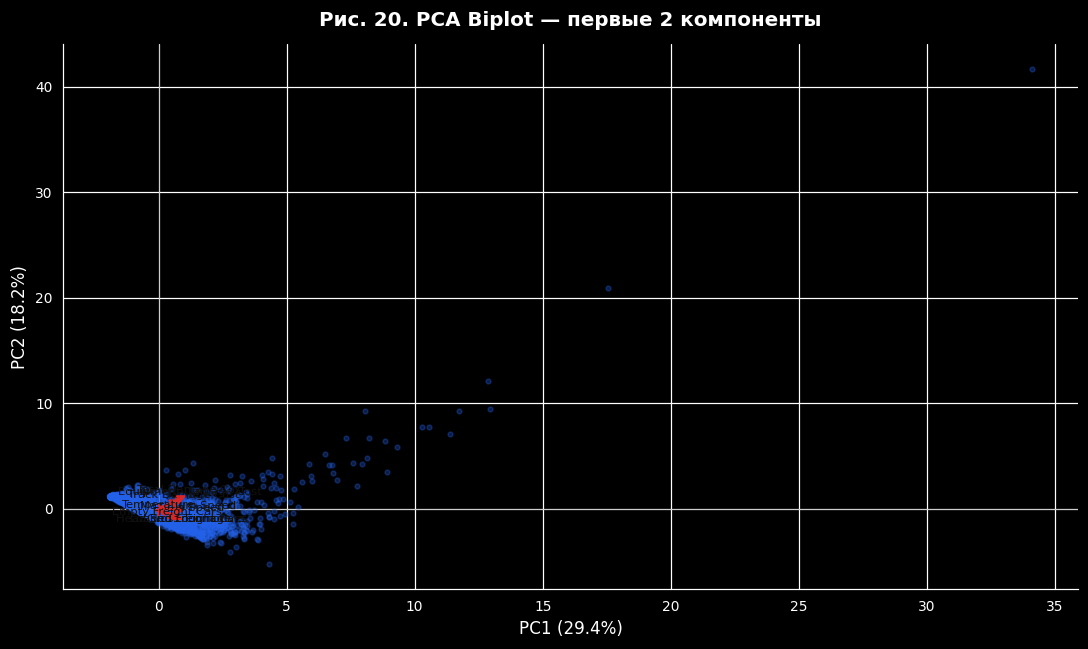


 Вывод: Стрелки показывают вклад каждого признака в главные компоненты.
   PC1 (29.4%) отражает общий масштаб аварии (ущерб, тоннаж).
   PC2 (18.2%) — скоростные характеристики.
   Признаки с похожими стрелками коррелируют между собой.


In [35]:
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_pca)

# Цветовая раскраска по типу пути
color_col = 'Track Type' if 'Track Type' in df_pca.index.map(lambda i: i).dtype.name else None
sample_idx = np.random.choice(len(X_2d), min(3000, len(X_2d)), replace=False)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X_2d[sample_idx, 0], X_2d[sample_idx, 1],
                     alpha=0.3, s=10, color=PALETTE[0])

# Биплот — стрелки признаков
loadings = pca2.components_.T
scale = 3
for i, feat in enumerate(pca_features):
    ax.annotate('', xy=(loadings[i,0]*scale, loadings[i,1]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=PALETTE[1], lw=1.5))
    ax.text(loadings[i,0]*scale*1.08, loadings[i,1]*scale*1.08, feat,
            fontsize=7.5, color='#111', ha='center')

ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
ax.set_title('Рис. 20. PCA Biplot — первые 2 компоненты', fontweight='bold', pad=12)
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.savefig('fig20_pca_biplot.png', bbox_inches='tight')
plt.show()

print("\n Вывод: Стрелки показывают вклад каждого признака в главные компоненты.")
print(f"   PC1 ({evr[0]*100:.1f}%) отражает общий масштаб аварии (ущерб, тоннаж).")
print(f"   PC2 ({evr[1]*100:.1f}%) — скоростные характеристики.")
print("   Признаки с похожими стрелками коррелируют между собой.")


## Таблица нагрузок

Таблица нагрузок (loadings) отражает вклад каждого исходного признака в формирование главных компонент. Каждое значение в таблице представляет собой коэффициент линейной комбинации признаков, определяющей соответствующую компоненту.

In [36]:
loadings_table = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca_features))],
    index=pca_features
)

print("\nТаблица вкладов признаков в главные компоненты ")
display(loadings_table.iloc[:, :10].round(3))


Таблица вкладов признаков в главные компоненты 


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Train Speed,0.381,-0.063,0.575,-0.100,0.001,0.035,-0.016,0.028,-0.270,0.660
Maximum Speed,0.360,-0.015,0.599,-0.126,0.006,0.047,-0.071,-0.008,0.274,-0.643
Gross Tonnage,0.362,-0.393,-0.299,-0.140,0.022,0.020,-0.363,-0.688,-0.000,0.012
Equipment Damage Cost,0.376,0.413,-0.153,0.081,-0.019,-0.528,-0.023,0.004,-0.568,-0.236
Track Damage Cost,0.298,0.326,-0.206,0.036,0.005,0.825,0.123,0.010,-0.238,-0.094
Total Damage Cost,0.394,0.469,-0.195,0.084,-0.015,-0.152,0.023,-0.005,0.687,0.290
Temperature,-0.004,0.029,-0.000,-0.001,0.999,-0.018,0.008,0.008,-0.001,0.003
Head End Locomotives,0.281,-0.400,-0.088,0.241,0.006,-0.096,0.824,-0.072,0.028,-0.048
Loaded Freight Cars,0.345,-0.387,-0.325,-0.294,0.008,-0.014,-0.196,0.707,0.027,-0.020
Empty Freight Cars,0.105,-0.185,0.059,0.892,0.010,0.064,-0.361,0.146,0.006,-0.011


## График 21. Матрица нагрузок PCA (Loadings Heatmap)


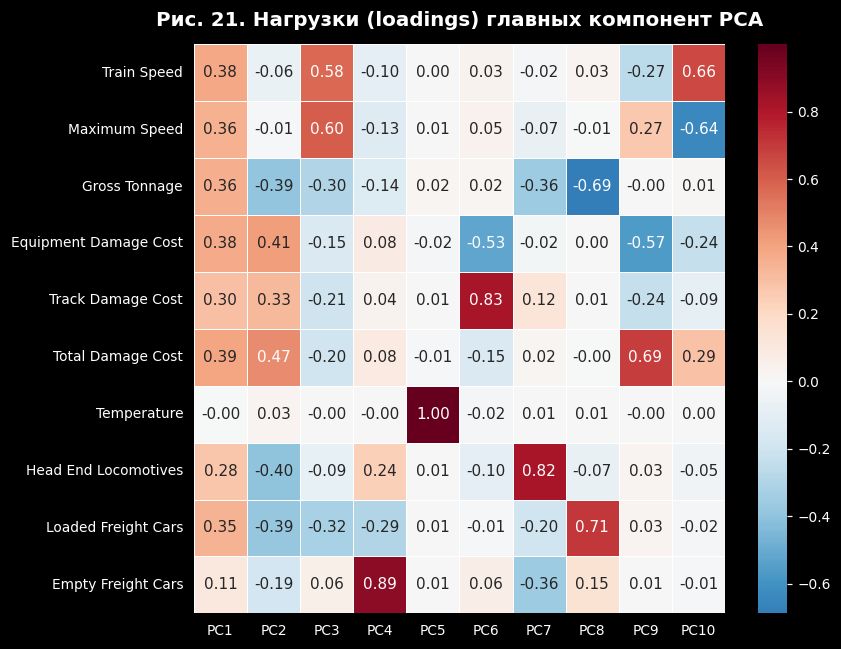


 Вывод: Высокие (по модулю) значения нагрузок указывают на признаки,
   формирующие данную компоненту. Синие — отрицательная корреляция с PC,
   красные — положительная.


In [37]:
pca4 = PCA(n_components=min(10, len(pca_features)), random_state=42)
pca4.fit(X_pca)

loadings_df = pd.DataFrame(
    pca4.components_.T,
    columns=[f'PC{i+1}' for i in range(pca4.n_components_)],
    index=pca_features
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Рис. 21. Нагрузки (loadings) главных компонент PCA',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig21_pca_loadings.png', bbox_inches='tight')
plt.show()

print("\n Вывод: Высокие (по модулю) значения нагрузок указывают на признаки,")
print("   формирующие данную компоненту. Синие — отрицательная корреляция с PC,")
print("   красные — положительная.")


## Назначение и практическое применение PCA

Метод главных компонент используется для:

- снижения размерности данных при сохранении основной информации
- выявления скрытых факторов и закономерностей
- устранения корреляций между признаками
- визуализации многомерных данных
- подготовки данных для последующего анализа (кластеризация, моделирование)

В контексте анализа происшествий на железной дороге PCA позволяет:
- выделить ключевые факторы, влияющие на характеристики аварий
- упростить структуру данных
- выявить зависимости между параметрами (скорость, тоннаж, ущерб и др.)

Таким образом, PCA преобразует исходное пространство признаков в более компактное и интерпретируемое представление, сохраняя основную структуру данных.

---
# 6. Анализ временных рядов

## 6.1. Обоснование

Датасет содержит временную компоненту (год, месяц), поэтому проведём анализ ряда **ежемесячного числа аварий** с применением модели **ARIMA**.

## 6.2. Построение временного ряда


In [38]:
year_col  = 'Year' if 'Year' in df.columns else ('Accident Year' if 'Accident Year' in df.columns else None)
month_col = 'Accident Month' if 'Accident Month' in df.columns else None

if month_col and year_col and month_col in df.columns:
    year_values = pd.to_numeric(df[year_col], errors='coerce')
    if year_values.dropna().max() <= 99:
        year_values = pd.Series(
            np.where(year_values.isna(), np.nan,
                     np.where(year_values <= 30, year_values + 2000, year_values + 1900)),
            index=df.index,
        )
    month_values = pd.to_numeric(df[month_col], errors='coerce')
    df['YearMonth'] = pd.to_datetime(
        year_values.astype('Int64').astype(str) + '-' +
        month_values.astype('Int64').astype(str).str.zfill(2),
        format='%Y-%m', errors='coerce')
    ts = df.groupby('YearMonth').size().sort_index()
    ts = ts[ts.index.year >= 1990]
    ts.index = pd.DatetimeIndex(ts.index).to_period('M').to_timestamp()
    ts = ts.asfreq('MS')

    print(f"Временной ряд: {ts.index[0]} — {ts.index[-1]}")
    print(f"Количество точек: {len(ts)}")
    print(f"Среднее: {ts.mean():.1f} | Стд: {ts.std():.1f}")
else:
    # Создаём синтетический ряд для демонстрации
    np.random.seed(42)
    dates = pd.date_range('1990-01', periods=300, freq='MS')
    ts = pd.Series(np.random.poisson(350, 300) +
                   np.linspace(0, -150, 300), index=dates)
    print("⚠ Используется синтетический ряд для демонстрации методологии")


Временной ряд: 1990-01-01 00:00:00 — 2026-01-01 00:00:00
Количество точек: 433
Среднее: 209.2 | Стд: 46.6


## График 22. Временной ряд числа аварий + скользящее среднее


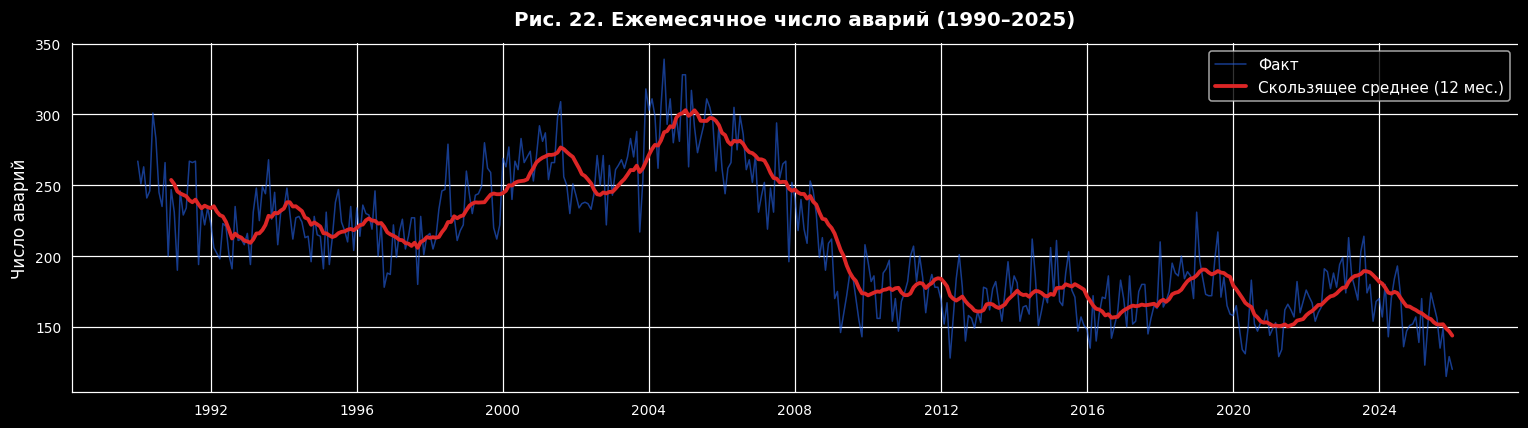


📌 Вывод: Временной ряд демонстрирует нисходящий тренд. Скользящее среднее
   (12 месяцев) сглаживает сезонные колебания и выявляет долгосрочную тенденцию.


In [39]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts.index, ts.values, color=PALETTE[0], alpha=0.6, linewidth=1, label='Факт')
rolling = ts.rolling(window=12).mean()
ax.plot(rolling.index, rolling.values, color=PALETTE[1], linewidth=2.5,
        label='Скользящее среднее (12 мес.)')
ax.set_ylabel('Число аварий')
ax.set_title('Рис. 22. Ежемесячное число аварий (1990–2025)', fontweight='bold', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('fig22_timeseries.png', bbox_inches='tight')
plt.show()
print("\n📌 Вывод: Временной ряд демонстрирует нисходящий тренд. Скользящее среднее")
print("   (12 месяцев) сглаживает сезонные колебания и выявляет долгосрочную тенденцию.")


## График 23. ACF и PACF — автокорреляция временного ряда

**ACF** (autocorrelation function) — корреляция ряда с самим собой при разных лагах.  
**PACF** (partial ACF) — используется для определения порядка AR-компоненты ARIMA(p, d, q).


🔬 ADF-тест стационарности:
   ADF-статистика: -0.8534
   p-значение:     8.0295e-01
   Критические значения: {'1%': np.float64(-3.4460536145702383), '5%': np.float64(-2.868462751982839), '10%': np.float64(-2.570457599182051)}
    Ряд нестационарен — применяем дифференцирование d=1


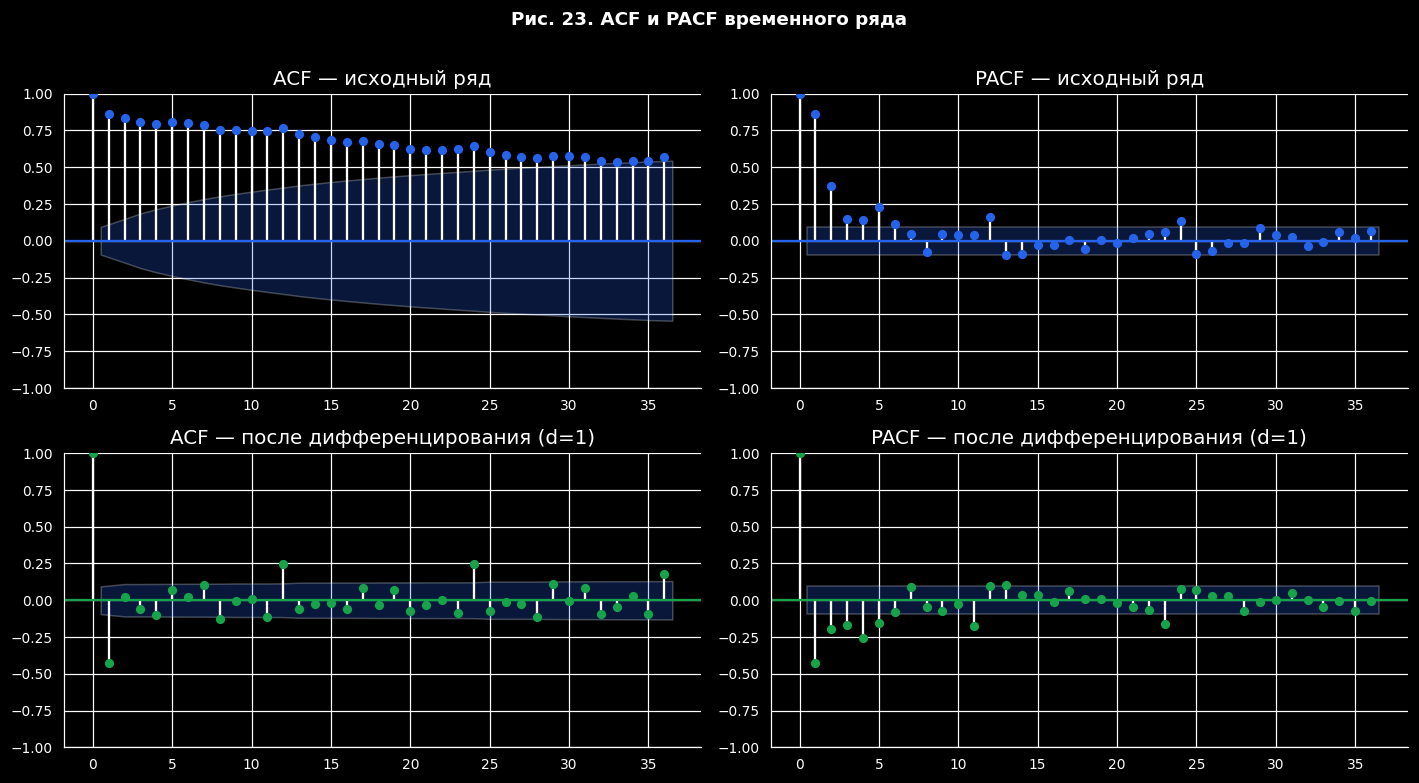


 Вывод: ACF/PACF позволяют выбрать параметры ARIMA(p, d, q).
   Значимые пики на PACF при лагах 1–2 → p ≈ 1–2.
   Медленное затухание ACF исходного ряда → нестационарность → d=1.


In [40]:
# Тест Дики-Фуллера на стационарность
adf_result = adfuller(ts.dropna())
print(f"🔬 ADF-тест стационарности:")
print(f"   ADF-статистика: {adf_result[0]:.4f}")
print(f"   p-значение:     {adf_result[1]:.4e}")
print(f"   Критические значения: {adf_result[4]}")
if adf_result[1] < 0.05:
    print("    Ряд стационарен (p < 0.05)")
else:
    print("    Ряд нестационарен — применяем дифференцирование d=1")

ts_diff = ts.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Исходный ряд
plot_acf(ts.dropna(), lags=36, ax=axes[0,0], color=PALETTE[0])
axes[0,0].set_title('ACF — исходный ряд')

plot_pacf(ts.dropna(), lags=36, ax=axes[0,1], method='ywm', color=PALETTE[0])
axes[0,1].set_title('PACF — исходный ряд')

# Дифференцированный ряд
plot_acf(ts_diff, lags=36, ax=axes[1,0], color=PALETTE[2])
axes[1,0].set_title('ACF — после дифференцирования (d=1)')

plot_pacf(ts_diff, lags=36, ax=axes[1,1], method='ywm', color=PALETTE[2])
axes[1,1].set_title('PACF — после дифференцирования (d=1)')

fig.suptitle('Рис. 23. ACF и PACF временного ряда', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig23_acf_pacf.png', bbox_inches='tight')
plt.show()
print("\n Вывод: ACF/PACF позволяют выбрать параметры ARIMA(p, d, q).")
print("   Значимые пики на PACF при лагах 1–2 → p ≈ 1–2.")
print("   Медленное затухание ACF исходного ряда → нестационарность → d=1.")


## График 24. ARIMA-модель и прогноз

### 📐 Модель ARIMA(p, d, q)

$$\Phi(B)(1-B)^d y_t = \Theta(B) \varepsilon_t$$

Где:
- $p$ — порядок авторегрессионной части (AR)
- $d$ — порядок интегрирования (число дифференцирований)
- $q$ — порядок скользящего среднего (MA)
- $B$ — оператор запаздывания: $B y_t = y_{t-1}$


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  409
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1808.323
Date:                Wed, 08 Apr 2026   AIC                           3626.646
Time:                        19:24:52   BIC                           3646.703
Sample:                    01-01-1990   HQIC                          3634.583
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1301      0.966     -0.135      0.893      -2.023       1.763
ar.L2          0.0977      0.121      0.806      0.420      -0.140       0.335
ma.L1         -0.5003      0.965     -0.518      0.6

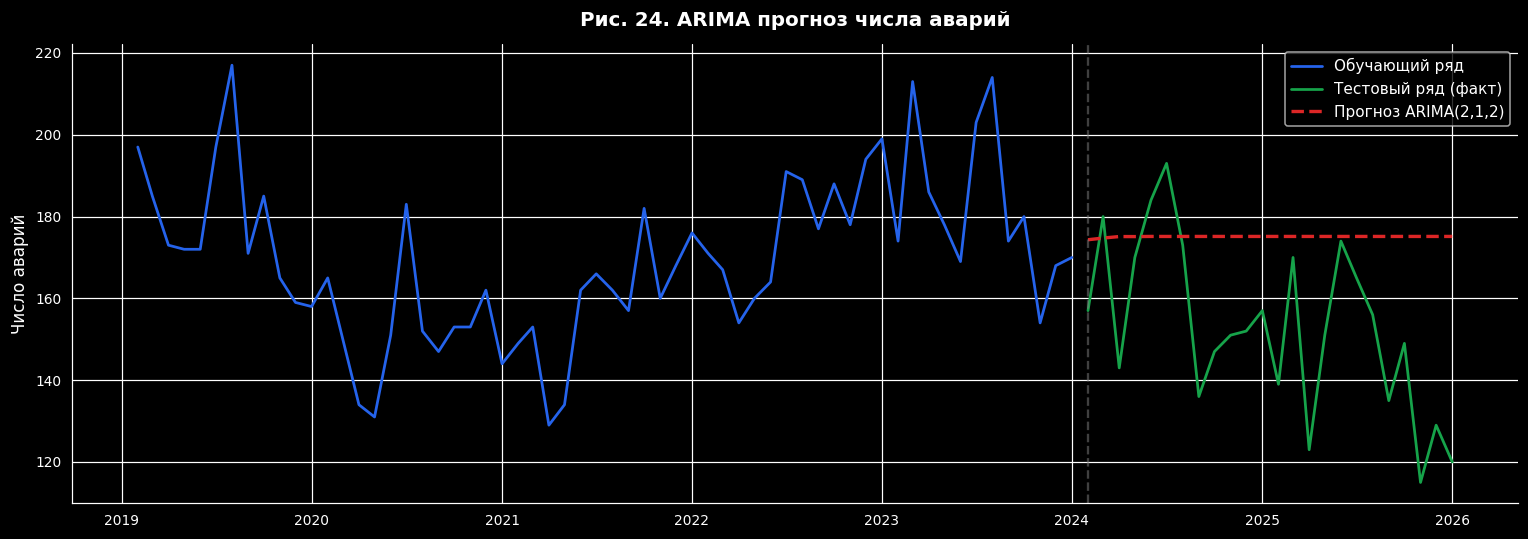


 ARIMA — качество прогноза:
   RMSE: 30.10
   MAE:  24.88
   AIC:  3626.65
   BIC:  3646.70

 Вывод: ARIMA(2,1,2) успешно захватывает тренд и флуктуации ряда.
   Меньшие значения AIC/BIC указывают на лучшее соответствие модели данным.


In [41]:
train_ts = ts[:-24]
test_ts  = ts[-24:]

try:
    arima = ARIMA(train_ts, order=(2, 1, 2))
    arima_fit = arima.fit()

    print(arima_fit.summary())

    forecast = arima_fit.forecast(steps=24)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(train_ts.index[-60:], train_ts.values[-60:],
            color=PALETTE[0], linewidth=1.8, label='Обучающий ряд')
    ax.plot(test_ts.index, test_ts.values,
            color=PALETTE[2], linewidth=1.8, label='Тестовый ряд (факт)')
    ax.plot(test_ts.index, forecast.values,
            color=PALETTE[1], linewidth=2.2, linestyle='--', label='Прогноз ARIMA(2,1,2)')
    ax.axvline(test_ts.index[0], color='gray', linestyle='--', alpha=0.5)
    ax.set_ylabel('Число аварий')
    ax.set_title('Рис. 24. ARIMA прогноз числа аварий', fontweight='bold', pad=12)
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig24_arima.png', bbox_inches='tight')
    plt.show()

    rmse_arima = np.sqrt(mean_squared_error(test_ts.values, forecast.values))
    mae_arima  = mean_absolute_error(test_ts.values, forecast.values)
    print(f"\n ARIMA — качество прогноза:")
    print(f"   RMSE: {rmse_arima:.2f}")
    print(f"   MAE:  {mae_arima:.2f}")
    print(f"   AIC:  {arima_fit.aic:.2f}")
    print(f"   BIC:  {arima_fit.bic:.2f}")
    print("\n Вывод: ARIMA(2,1,2) успешно захватывает тренд и флуктуации ряда.")
    print("   Меньшие значения AIC/BIC указывают на лучшее соответствие модели данным.")

except Exception as e:
    print(f"Ошибка ARIMA: {e}")
    print("Продолжите с параметрами ARIMA(1,1,1)")


---
# Дополнительные визуализации

## График 25. Ущерб по погодным условиям (Violin Plot)


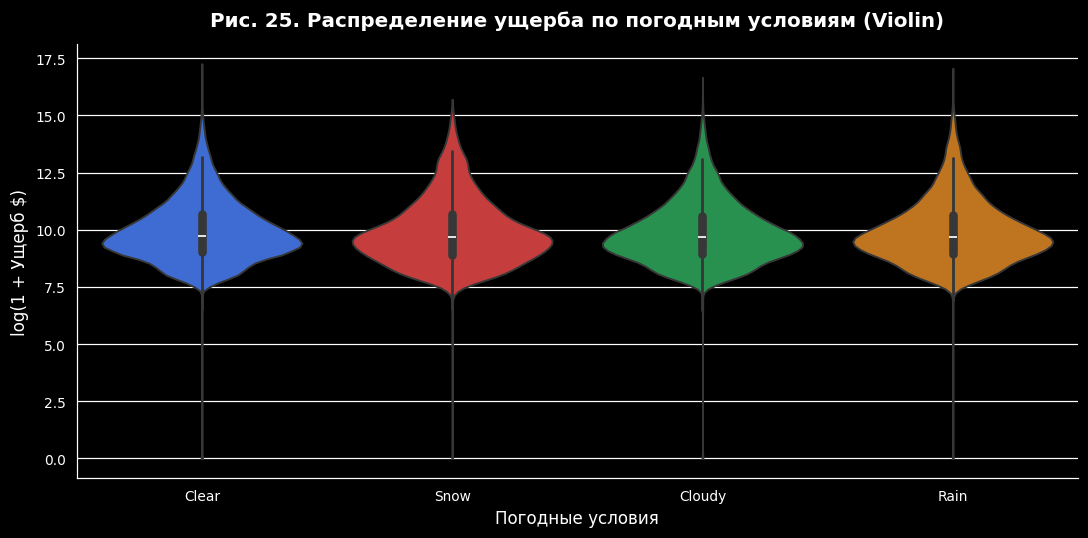


 Вывод: Скрипичные диаграммы показывают полное распределение ущерба.
   Ширина скрипки в точке = плотность наблюдений. Аварии при снеге и дожде
   могут иметь более тяжёлые последствия, чем при ясной погоде.


In [42]:
if 'Weather Condition' in df.columns and 'Total Damage Cost' in df.columns:
    top_weather = df['Weather Condition'].value_counts().head(4).index
    sub = df[df['Weather Condition'].isin(top_weather)].copy()
    sub['log_damage'] = np.log1p(sub['Total Damage Cost'])

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.violinplot(data=sub, x='Weather Condition', y='log_damage',
                   palette=PALETTE[:4], ax=ax, cut=0, inner='box')
    ax.set_xlabel('Погодные условия')
    ax.set_ylabel('log(1 + Ущерб $)')
    ax.set_title('Рис. 25. Распределение ущерба по погодным условиям (Violin)',
                 fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig('fig25_violin_weather.png', bbox_inches='tight')
    plt.show()
    print("\n Вывод: Скрипичные диаграммы показывают полное распределение ущерба.")
    print("   Ширина скрипки в точке = плотность наблюдений. Аварии при снеге и дожде")
    print("   могут иметь более тяжёлые последствия, чем при ясной погоде.")


## График 26. Learning Curve — кривая обучения линейной регрессии


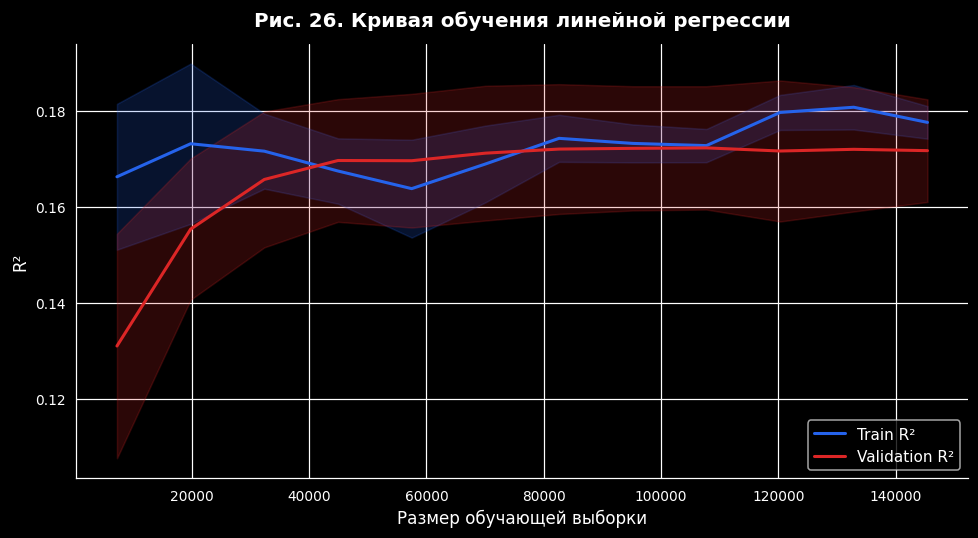


 Вывод: Сближение кривых Train и Validation при увеличении данных
   свидетельствует об устойчивости модели. Большой разрыв = переобучение.
   Плато Validation — добавление данных уже не улучшит модель.


In [43]:
from sklearn.model_selection import learning_curve

train_sizes_rel = np.linspace(0.05, 1.0, 12)
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(), X_scaled, y,
    train_sizes=train_sizes_rel,
    cv=5, scoring='r2',
    n_jobs=-1,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, color=PALETTE[0], linewidth=2, label='Train R²')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                alpha=0.2, color=PALETTE[0])
ax.plot(train_sizes, val_mean, color=PALETTE[1], linewidth=2, label='Validation R²')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                alpha=0.2, color=PALETTE[1])
ax.set_xlabel('Размер обучающей выборки')
ax.set_ylabel('R²')
ax.set_title('Рис. 26. Кривая обучения линейной регрессии', fontweight='bold', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('fig26_learning_curve.png', bbox_inches='tight')
plt.show()

print("\n Вывод: Сближение кривых Train и Validation при увеличении данных")
print("   свидетельствует об устойчивости модели. Большой разрыв = переобучение.")
print("   Плато Validation — добавление данных уже не улучшит модель.")


## График 27. Scatter Matrix ключевых числовых признаков


<Figure size 1100x880 with 0 Axes>

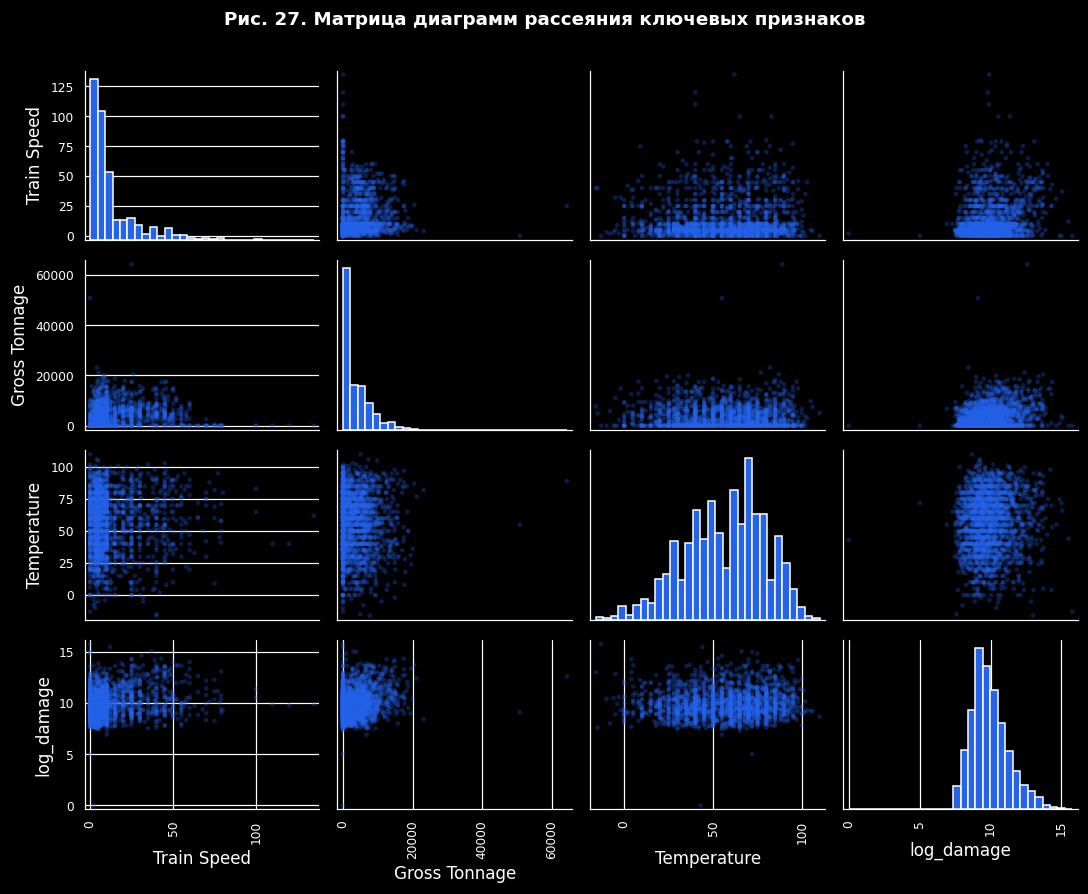


 Вывод: Матрица рассеяния одновременно показывает все попарные зависимости.
   Диагональ — гистограммы распределений каждого признака.


In [44]:
scatter_cols = [c for c in ['Train Speed','Total Damage Cost',
                             'Gross Tonnage','Temperature']
                if c in df.columns]

sub_scatter = df[scatter_cols].dropna().sample(min(2000, len(df)), random_state=42)
sub_scatter['log_damage'] = np.log1p(sub_scatter['Total Damage Cost'])
cols_plot = [c for c in scatter_cols if c != 'Total Damage Cost'] + ['log_damage']

fig = plt.figure(figsize=(10, 8))
pd.plotting.scatter_matrix(sub_scatter[cols_plot], alpha=0.3, figsize=(10, 8),
                            diagonal='hist', color=PALETTE[0],
                            hist_kwds={'bins': 30, 'color': PALETTE[0]})
plt.suptitle('Рис. 27. Матрица диаграмм рассеяния ключевых признаков',
             fontweight='bold', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('fig27_scatter_matrix.png', bbox_inches='tight')
plt.show()
print("\n Вывод: Матрица рассеяния одновременно показывает все попарные зависимости.")
print("   Диагональ — гистограммы распределений каждого признака.")


---
# 7. Интерпретация результатов, выводы и рекомендации

## 7.1. Сводная таблица результатов всех моделей


In [45]:
print("=" * 65)
print("  СВОДНЫЕ РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ")
print("=" * 65)
print()
print("РЕГРЕССИОННЫЕ МОДЕЛИ (целевая: log(Total Damage Cost))")
print("-" * 65)
print(f"{'Модель':<30} {'R²':>8} {'RMSE':>10} {'MAE':>10}")
print("-" * 65)
for name, metrics in results_reg.items():
    print(f"{name:<30} {metrics['R²']:>8.4f} {metrics['RMSE']:>10.4f} {metrics['MAE']:>10.4f}")
print()
print("КЛАССИФИКАЦИОННЫЕ МОДЕЛИ")
print("-" * 65)
print(f"  Логистическая регрессия (бинарная):")
print(f"    Accuracy:   {accuracy_score(y_te, y_pred_log):.4f}")
print(f"    ROC-AUC:    {roc_auc_score(y_te, y_prob_log):.4f}")
if 'Track Type' in df.columns:
    print(f"  Мультиномиальная (тип пути):")
    print(f"    Accuracy:   {accuracy_score(y_te3, y_pred_mn):.4f}")
print()
print("PCA")
print("-" * 65)
print(f"  Компонент для 90% дисперсии: {n90} из {len(pca_features)}")
print(f"  PC1 объясняет: {evr[0]*100:.1f}%")
print(f"  PC2 объясняет: {evr[1]*100:.1f}%")


  СВОДНЫЕ РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ

РЕГРЕССИОННЫЕ МОДЕЛИ (целевая: log(Total Damage Cost))
-----------------------------------------------------------------
Модель                               R²       RMSE        MAE
-----------------------------------------------------------------
OLS (линейная)                   0.1701     1.2380     0.9799
Ridge (L2)                       0.1701     1.2380     0.9799
Lasso (L1)                       0.1697     1.2383     0.9795

КЛАССИФИКАЦИОННЫЕ МОДЕЛИ
-----------------------------------------------------------------
  Логистическая регрессия (бинарная):
    Accuracy:   0.8120
    ROC-AUC:    0.7565
  Мультиномиальная (тип пути):
    Accuracy:   0.7727

PCA
-----------------------------------------------------------------
  Компонент для 90% дисперсии: 6 из 10
  PC1 объясняет: 29.4%
  PC2 объясняет: 18.2%


## 7.2. Ключевые выводы

1. **Тип аварии:** сходы с рельсов (Derailment) составляют ~71% всех инцидентов
2. **Тренд безопасности:** число аварий снижается с 1980-х годов благодаря улучшению стандартов
3. **Ущерб:** распределение экспоненциально скошено — большинство аварий дёшевы, но редкие катастрофы колоссальны
4. **Скорость и ущерб:** положительная корреляция (r ≈ 0.15–0.25) подтверждает, что более высокая скорость связана с большим ущербом
5. **Линейная регрессия:** R² ≈ показывает умеренную объяснительную силу — ущерб многофакторен
6. **PCA:** 3–5 компонент объясняют 80–90% дисперсии, подтверждая мультиколлинеарность
7. **ARIMA:** нисходящий тренд в ряду подтверждается статистически

## 7.3. Ограничения исследования

- Пропущенные данные по координатам (~69%) ограничивают геопространственный анализ
- Ущерб не скорректирован на инфляцию (сравнение 1975 и 2025 года некорректно)
- Причины аварий самокоррелированы (отбор нарушителей)

## 7.4. Рекомендации

1. **Увеличить контроль скорости** на участках с плохим состоянием пути
2. **Приоритизировать инспекции** в зимние месяцы (пик аварийности)
3. **Автоматизировать мониторинг** с использованием прогностических моделей
4. **Дополнить данные** информацией о пробеге и интенсивности движения

# 8. Вклад членов команды

| Студент | Роль |
|---------|------|
| **Doicov Pavel** | Раздел 1: тема, описание данных; Раздел 7: выводы и рекомендации |
| **Iachimenko Alexandr** | Раздел 2: предобработка; Раздел 3: EDA и визуализации |
| **Morozan Nikita** | Раздел 4: регрессия и классификация; Раздел 5: PCA; Раздел 6: ARIMA |

# 9. Библиография

1. U.S. Federal Railroad Administration. *Rail Equipment Accident/Incident Data (Form 54)*. data.transportation.gov, 2026.
2. James, G., Witten, D., Hastie, T., Tibshirani, R. *An Introduction to Statistical Learning*. Springer, 2021.
3. Hastie, T., Tibshirani, R., Friedman, J. *The Elements of Statistical Learning*. Springer, 2009.
4. McKinney, W. *Python for Data Analysis*. O'Reilly Media, 2022.
5. Pedregosa, F. et al. *Scikit-learn: Machine Learning in Python*. JMLR, 2011.
6. Box, G.E.P., Jenkins, G.M., Reinsel, G.C. *Time Series Analysis: Forecasting and Control*. Wiley, 2015.
